# 3. Opis skupa podataka

Ova bilježnica sadrži cjelovitu analizu skupa podataka `bank-additional-ful-nominal.arff`: opis
strukture i distribucije atributa, analizu nedostajućih vrijednosti, statističke pokazatelje
asocijacije među atributima (entropija, Cramérov V) te analizu rijetkih kategorija i dupliciranih
zapisa. Nalazi ove analize čine osnovu poglavlja 3 završnog rada te pripremaju teren za odluke o
čišćenju i pretprocesiranju podataka u poglavlju 4.

## 3.0 Priprema okruženja

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, entropy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
})

SLIKE_DIR = 'slike'
REZULTATI_DIR = 'rezultati'
os.makedirs(SLIKE_DIR, exist_ok=True)
os.makedirs(REZULTATI_DIR, exist_ok=True)

DATA_PATH = 'bank-additional-ful-nominal.arff'


## 3.1 Učitavanje podataka

Skup podataka je u Weka ARFF formatu. Budući da su svi atributi nominalni (kategorički), datoteka
se učitava jednostavnim parserom koji iz `@attribute` redaka očitava nazive atributa i dopuštene
kategorije, a podatkovne retke (nakon `@data`) učitava kao tablicu.

In [2]:
def load_arff_nominal(path):
    attributes = []
    categories = {}
    data_start = None

    with open(path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.lower().startswith('@attribute'):
            parts = stripped.split(None, 2)
            name = parts[1]
            cats_raw = parts[2].strip()
            assert cats_raw.startswith('{') and cats_raw.endswith('}'), f"Neočekivan format atributa: {stripped}"
            cats = [c.strip() for c in cats_raw[1:-1].split(',')]
            attributes.append(name)
            categories[name] = cats
        elif stripped.lower().startswith('@data'):
            data_start = i + 1
            break

    assert data_start is not None, "Nije pronađen '@data' marker u ARFF datoteci."

    rows = [l.strip().split(',') for l in lines[data_start:] if l.strip()]
    df = pd.DataFrame(rows, columns=attributes)

    for col in attributes:
        df[col] = pd.Categorical(df[col], categories=categories[col])

    return df, categories


df, category_map = load_arff_nominal(DATA_PATH)
print(f"Dimenzije skupa podataka: {df.shape[0]} zapisa x {df.shape[1]} atributa")
df.head(10)


Dimenzije skupa podataka: 41188 zapisa x 11 atributa


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no
5,services,married,basic.9y,unknown,no,no,telephone,may,mon,nonexistent,no
6,admin.,married,professional.course,no,no,no,telephone,may,mon,nonexistent,no
7,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,nonexistent,no
8,technician,single,professional.course,no,yes,no,telephone,may,mon,nonexistent,no
9,services,single,high.school,no,yes,no,telephone,may,mon,nonexistent,no


In [3]:
# Provjera da nema praznih/nedostajućih (NaN) vrijednosti nakon učitavanja
# -- kategorija 'unknown' je legitimna vrijednost, a ne NaN
missing_nan = df.isna().sum()
print("Broj NaN vrijednosti po atributu (očekivano: 0 za sve):")
print(missing_nan)
assert missing_nan.sum() == 0, "Pronađene su prave NaN vrijednosti - provjeriti parsiranje."


Broj NaN vrijednosti po atributu (očekivano: 0 za sve):
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
poutcome       0
y              0
dtype: int64


## 3.2 Struktura atributa

Tablica u nastavku odgovara tablici `tab:opis-atributa` iz poglavlja 3: naziv atributa, broj
kategorija te popis kategorija.

In [4]:
attr_overview = pd.DataFrame({
    'Atribut': list(category_map.keys()),
    'Broj kategorija': [len(v) for v in category_map.values()],
    'Kategorije': [', '.join(v) for v in category_map.values()],
})
attr_overview.to_csv(f'{REZULTATI_DIR}/3_2_opis_atributa.csv', index=False)
attr_overview


,Atribut,Broj kategorija,Kategorije
0,job,12,"housemaid, services, admin., blue-collar, tech..."
1,marital,4,"married, single, divorced, unknown"
2,education,8,"basic.4y, high.school, basic.6y, basic.9y, pro..."
3,default,3,"no, unknown, yes"
4,housing,3,"no, yes, unknown"
5,loan,3,"no, yes, unknown"
6,contact,2,"telephone, cellular"
7,month,10,"may, jun, jul, aug, oct, nov, dec, mar, apr, sep"
8,day_of_week,5,"mon, tue, wed, thu, fri"
9,poutcome,3,"nonexistent, failure, success"


In [5]:
n_predictors = attr_overview.loc[attr_overview['Atribut'] != 'y', 'Broj kategorija'].sum()
print(f"Ukupan broj kategorija kod 10 prediktorskih atributa (bez 'y'): {n_predictors}")


Ukupan broj kategorija kod 10 prediktorskih atributa (bez 'y'): 53


## 3.3 Distribucija kategorija po atributu

Za svaki atribut izračunata je apsolutna i relativna (%) učestalost svake kategorije, te je
istaknuta najzastupljenija kategorija.

In [6]:
predictor_cols = [c for c in df.columns if c != 'y']

dist_tables = {}
most_frequent_summary = []

for col in df.columns:
    vc = df[col].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(2)
    table = pd.DataFrame({'broj': vc, 'postotak (%)': pct})
    dist_tables[col] = table
    top_cat = vc.index[0]
    most_frequent_summary.append({
        'Atribut': col,
        'Najzastupljenija kategorija': top_cat,
        'Broj': int(vc.iloc[0]),
        'Postotak (%)': float(pct.iloc[0]),
    })

most_frequent_df = pd.DataFrame(most_frequent_summary)
most_frequent_df.to_csv(f'{REZULTATI_DIR}/3_3_najzastupljenije_kategorije.csv', index=False)
most_frequent_df


,Atribut,Najzastupljenija kategorija,Broj,Postotak (%)
0,job,admin.,10422,25.30
1,marital,married,24928,60.52
2,education,university.degree,12168,29.54
3,default,no,32588,79.12
4,housing,yes,21576,52.38
5,loan,no,33950,82.43
6,contact,cellular,26144,63.47
7,month,may,13769,33.43
8,day_of_week,thu,8623,20.94
9,poutcome,nonexistent,35563,86.34


In [7]:
# Detaljan ispis distribucije za svaki atribut
for col in df.columns:
    print(f"\n--- {col} ---")
    print(dist_tables[col])



--- job ---
                broj  postotak (%)
job                               
admin.         10422         25.30
blue-collar     9254         22.47
technician      6743         16.37
services        3969          9.64
management      2924          7.10
retired         1720          4.18
entrepreneur    1456          3.54
self-employed   1421          3.45
housemaid       1060          2.57
unemployed      1014          2.46
student          875          2.12
unknown          330          0.80

--- marital ---
           broj  postotak (%)
marital                      
married   24928         60.52
single    11568         28.09
divorced   4612         11.20
unknown      80          0.19

--- education ---
                      broj  postotak (%)
education                               
university.degree    12168         29.54
high.school           9515         23.10
basic.9y              6045         14.68
professional.course   5243         12.73
basic.4y              4176         

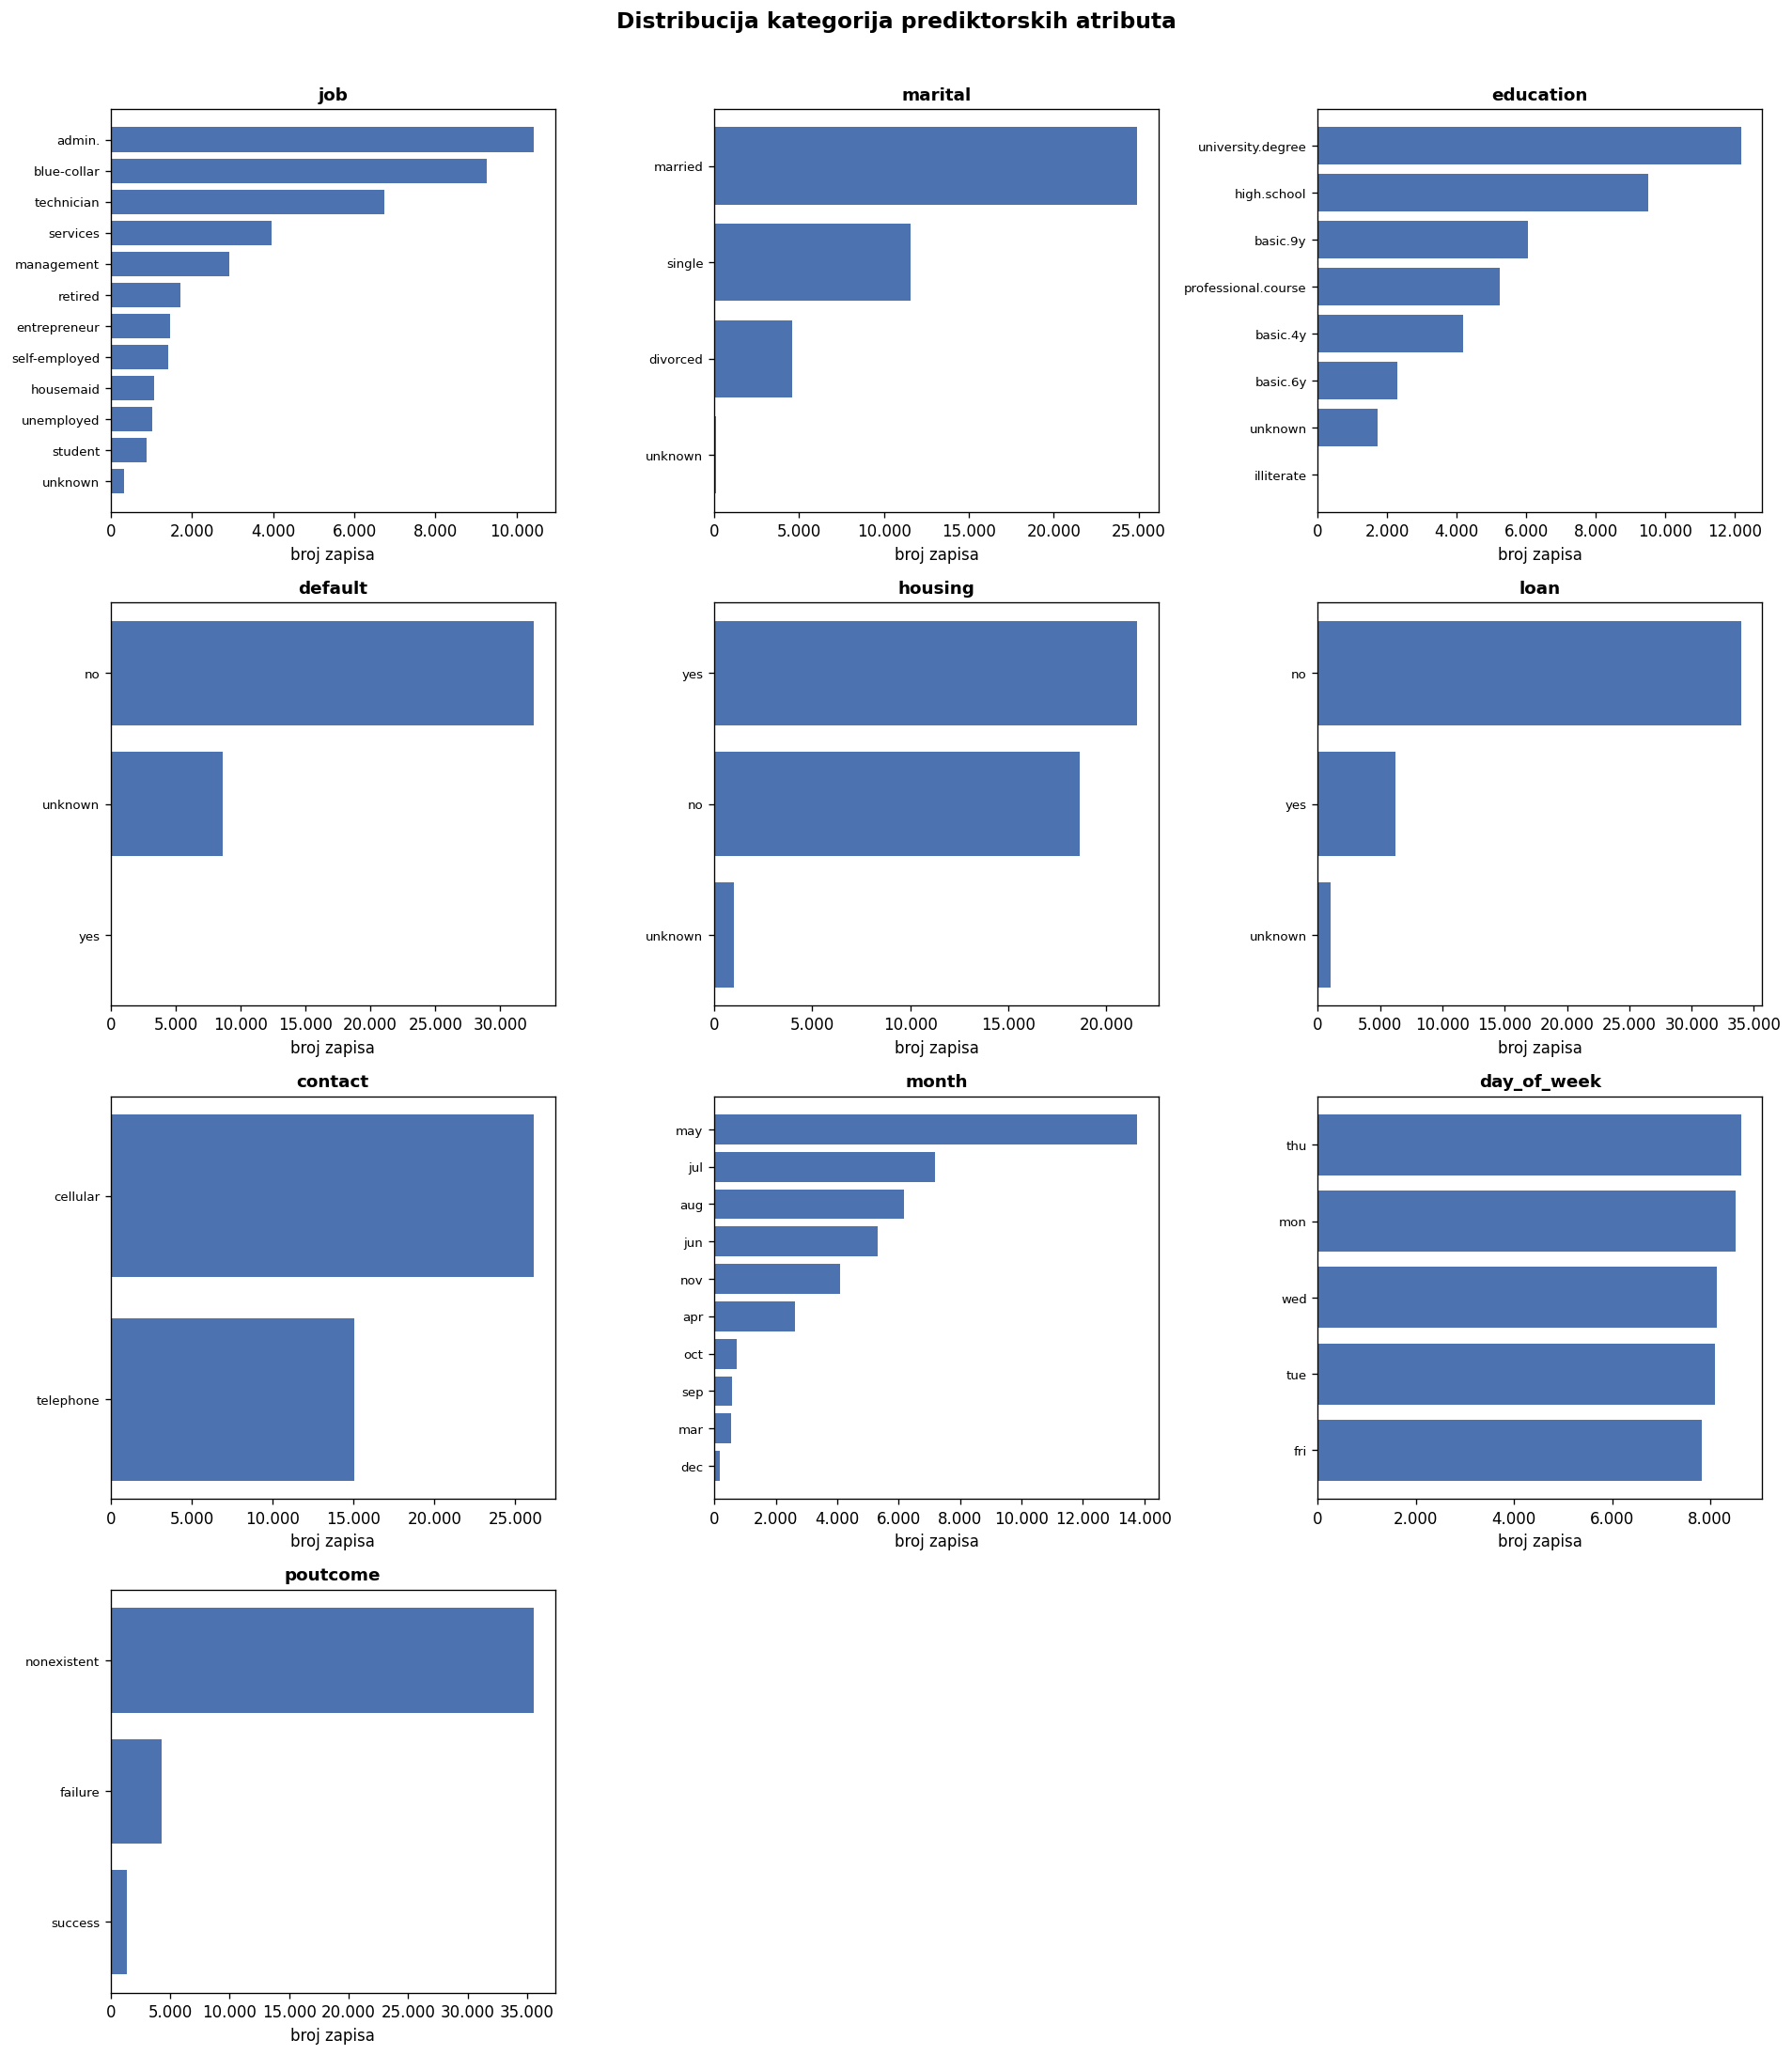

In [8]:
# Vizualizacija distribucije svih 10 prediktorskih atributa
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for ax, col in zip(axes, predictor_cols):
    vc = df[col].value_counts()
    vc = vc.sort_values(ascending=True)
    bars = ax.barh(vc.index.astype(str), vc.values, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel('broj zapisa')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    ax.tick_params(axis='y', labelsize=8)

for ax in axes[len(predictor_cols):]:
    ax.axis('off')

fig.suptitle('Distribucija kategorija prediktorskih atributa', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/distribucije_atributa.png')
plt.show()


## 3.4 Nedostajuće vrijednosti (kategorija „unknown")

Kod 6 od 11 atributa postoji kategorija `unknown`, koja predstavlja nedostajuću vrijednost.
Napomena: `poutcome = nonexistent` **nije** nedostajuća vrijednost, nego legitimna kategorija
(označava da prethodna kampanja nije postojala za tog klijenta), pa se ne ubraja u ovu analizu.

In [9]:
unknown_candidates = [c for c in predictor_cols if 'unknown' in category_map[c]]
print("Atributi s kategorijom 'unknown':", unknown_candidates)

missing_summary = []
for col in unknown_candidates:
    n_unknown = int((df[col] == 'unknown').sum())
    pct_unknown = round(n_unknown / len(df) * 100, 2)
    missing_summary.append({'Atribut': col, 'Broj "unknown"': n_unknown, 'Postotak (%)': pct_unknown})

missing_df = pd.DataFrame(missing_summary).sort_values('Broj "unknown"', ascending=False).reset_index(drop=True)
missing_df.to_csv(f'{REZULTATI_DIR}/3_4_nedostajuce_vrijednosti.csv', index=False)
missing_df


Atributi s kategorijom 'unknown': ['job', 'marital', 'education', 'default', 'housing', 'loan']


,Atribut,"Broj ""unknown""",Postotak (%)
0,default,8597,20.87
1,education,1731,4.20
2,housing,990,2.40
3,loan,990,2.40
4,job,330,0.80
5,marital,80,0.19


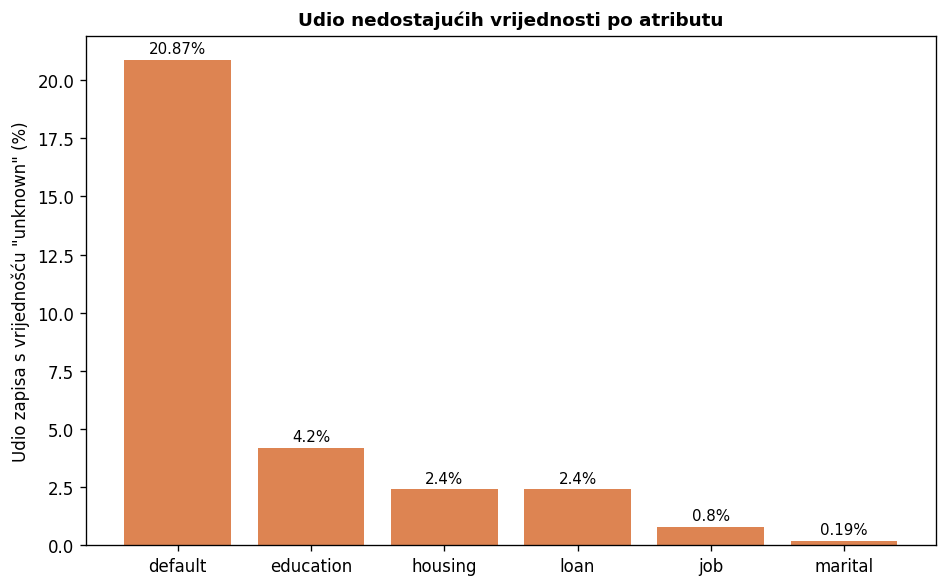

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(missing_df['Atribut'], missing_df['Postotak (%)'], color='#DD8452')
ax.set_ylabel('Udio zapisa s vrijednošću "unknown" (%)')
ax.set_title('Udio nedostajućih vrijednosti po atributu')
for b, val in zip(bars, missing_df['Postotak (%)']):
    ax.text(b.get_x() + b.get_width() / 2, val + 0.3, f'{val}%', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/nedostajuce_vrijednosti.png')
plt.show()


In [11]:
# Koliko zapisa ima barem jednu, a koliko dvije ili više nedostajućih (unknown) vrijednosti?
unknown_count_per_row = (df[unknown_candidates] == 'unknown').sum(axis=1)
rows_with_ge1 = int((unknown_count_per_row >= 1).sum())
rows_with_ge2 = int((unknown_count_per_row >= 2).sum())

print(f"Zapisa s barem 1 nedostajućom vrijednosti: {rows_with_ge1} ({rows_with_ge1/len(df)*100:.2f}%)")
print(f"Zapisa s 2 ili više nedostajućih vrijednosti: {rows_with_ge2} ({rows_with_ge2/len(df)*100:.2f}%)")
print("\nRaspodjela broja nedostajućih vrijednosti po zapisu:")
print(unknown_count_per_row.value_counts().sort_index())


Zapisa s barem 1 nedostajućom vrijednosti: 10700 (25.98%)
Zapisa s 2 ili više nedostajućih vrijednosti: 1666 (4.04%)

Raspodjela broja nedostajućih vrijednosti po zapisu:
0    30488
1     9034
2     1338
3      306
4       20
5        2
Name: count, dtype: int64


## 3.5 Ciljna varijabla `y` i neravnoteža razreda

`y` označava ishod marketinške kampanje (je li klijent prihvatio ponudu), a **ne** izvornu oznaku
anomalije. U poglavlju 4 koristit će se kao proxy referenca za evaluaciju modela za otkrivanje
anomalija, uz eksplicitno navođenje ograničenja takvog pristupa.

In [12]:
y_counts = df['y'].value_counts()
y_pct = (y_counts / len(df) * 100).round(2)
y_summary = pd.DataFrame({'broj': y_counts, 'postotak (%)': y_pct})
y_summary.to_csv(f'{REZULTATI_DIR}/3_5_y_distribucija.csv')
y_summary


,broj,postotak (%)
y,,
no,36548,88.73
yes,4640,11.27


Omjer većinske prema manjinskoj klasi (no : yes) = 7.88 : 1


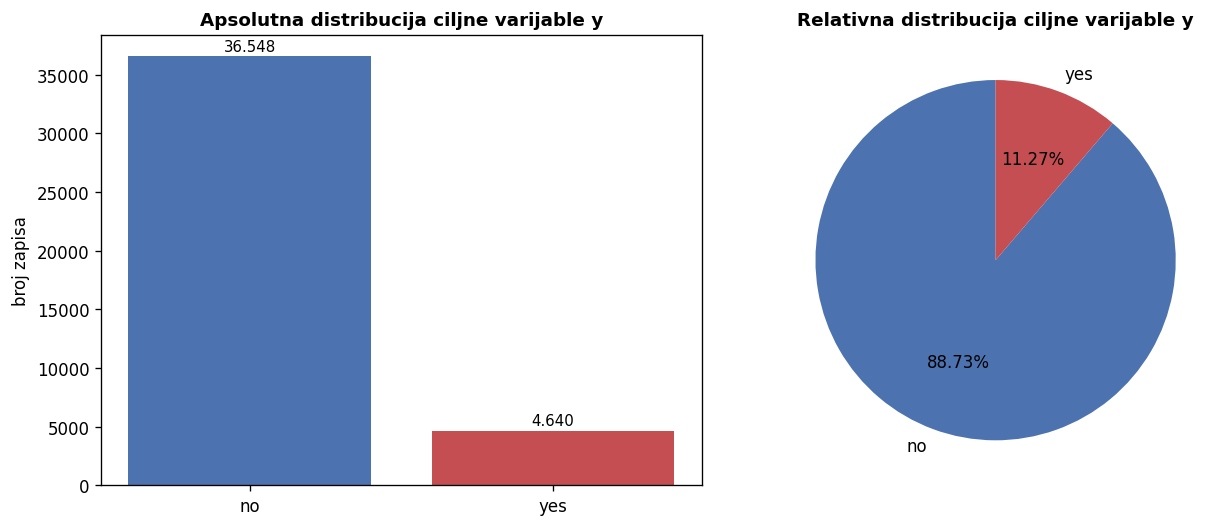

In [13]:
ratio = y_counts['no'] / y_counts['yes']
print(f"Omjer većinske prema manjinskoj klasi (no : yes) = {ratio:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(y_summary.index.astype(str), y_summary['broj'], color=['#4C72B0', '#C44E52'])
axes[0].set_title('Apsolutna distribucija ciljne varijable y')
axes[0].set_ylabel('broj zapisa')
for i, val in enumerate(y_summary['broj']):
    axes[0].text(i, val + 500, f'{val:,}'.replace(',', '.'), ha='center', fontsize=9)

axes[1].pie(y_summary['broj'], labels=y_summary.index.astype(str), autopct='%1.2f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90)
axes[1].set_title('Relativna distribucija ciljne varijable y')

fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/y_distribucija.png')
plt.show()


## 3.6 Entropija distribucije atributa

Shannonova entropija mjeri koliko je distribucija kategorija unutar atributa „neravnomjerna"
(koncentrirana na malo kategorija) ili „ravnomjerna". Entropija je normalizirana na raspon [0, 1]
dijeljenjem s maksimalnom mogućom entropijom ($\log_2 k$, gdje je $k$ broj kategorija) kako bi
atributi s različitim brojem kategorija bili usporedivi. Niža normalizirana entropija upućuje na
atribut kod kojeg je nekoliko kategorija dominantno, a preostale su relativno rijetke — što je
relevantno za detekciju anomalija jer takvi atributi lakše generiraju rijetke, potencijalno
anomalne kombinacije kategorija.

In [14]:
entropy_summary = []
for col in df.columns:
    counts = df[col].value_counts()
    probs = counts / counts.sum()
    h = entropy(probs, base=2)
    h_max = np.log2(len(probs))
    entropy_summary.append({
        'Atribut': col,
        'Broj kategorija': len(probs),
        'Entropija (bit)': round(h, 3),
        'Maks. entropija (bit)': round(h_max, 3),
        'Normalizirana entropija': round(h / h_max, 3) if h_max > 0 else np.nan,
    })

entropy_df = pd.DataFrame(entropy_summary).sort_values('Normalizirana entropija').reset_index(drop=True)
entropy_df.to_csv(f'{REZULTATI_DIR}/3_6_entropija_atributa.csv', index=False)
entropy_df


,Atribut,Broj kategorija,Entropija (bit),Maks. entropija (bit),Normalizirana entropija
0,poutcome,3,0.685,1.585,0.432
1,default,3,0.740,1.585,0.467
2,loan,3,0.772,1.585,0.487
3,y,2,0.508,1.000,0.508
4,marital,4,1.324,2.000,0.662
5,housing,3,1.136,1.585,0.717
6,month,10,2.649,3.322,0.797
7,job,12,2.980,3.585,0.831
8,education,8,2.557,3.000,0.852
9,contact,2,0.947,1.000,0.947


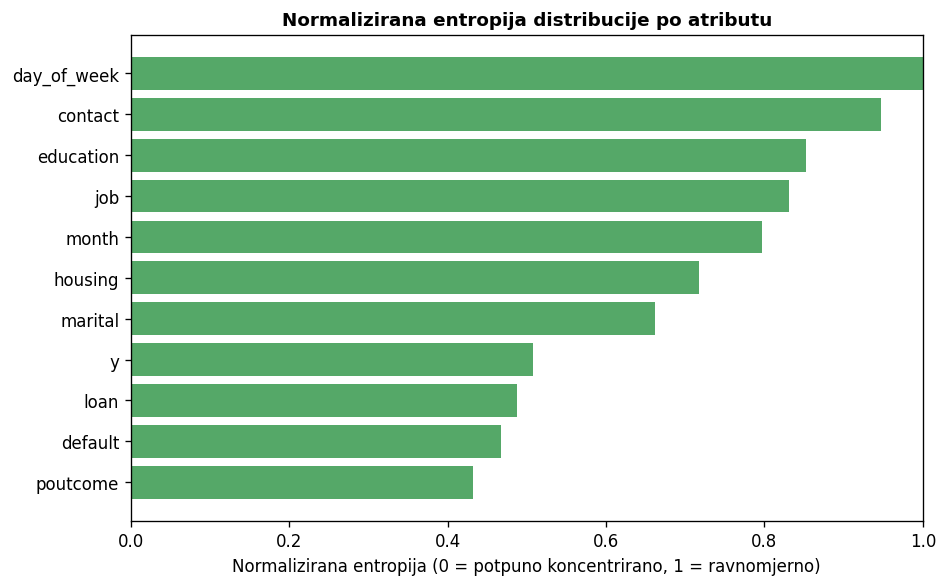

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
order = entropy_df.sort_values('Normalizirana entropija')
bars = ax.barh(order['Atribut'], order['Normalizirana entropija'], color='#55A868')
ax.set_xlabel('Normalizirana entropija (0 = potpuno koncentrirano, 1 = ravnomjerno)')
ax.set_title('Normalizirana entropija distribucije po atributu')
ax.set_xlim(0, 1)
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/entropija_atributa.png')
plt.show()


## 3.7 Povezanost prediktorskih atributa s ciljnom varijablom `y`

Za svaki prediktorski atribut izrađena je tablica kontingencije s `y`, izračunat je $\chi^2$ test
neovisnosti te Cramérov V kao mjera jakosti asocijacije (0 = nema asocijacije, 1 = savršena
asocijacija). Ovo ukazuje koji su atributi potencijalno najinformativniji predznaci ishoda
kampanje, što je korisno za interpretaciju rezultata modela u poglavlju 5.

In [16]:
def cramers_v(confusion_matrix):
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))
    return v, chi2, p

assoc_with_y = []
for col in predictor_cols:
    ct = pd.crosstab(df[col], df['y'])
    v, chi2_stat, p_val = cramers_v(ct)
    assoc_with_y.append({
        'Atribut': col,
        "Cramerov V": round(v, 3),
        'chi2': round(chi2_stat, 1),
        'p-vrijednost': p_val,
    })

assoc_with_y_df = pd.DataFrame(assoc_with_y).sort_values("Cramerov V", ascending=False).reset_index(drop=True)
assoc_with_y_df.to_csv(f'{REZULTATI_DIR}/3_7_asocijacija_s_y.csv', index=False)
assoc_with_y_df


,Atribut,Cramerov V,chi2,p-vrijednost
0,poutcome,0.320,4230.5,0.000000e+00
1,month,0.274,3101.1,0.000000e+00
2,job,0.153,961.2,4.189763e-199
3,contact,0.145,862.3,1.525986e-189
4,default,0.099,406.6,5.161958e-89
5,education,0.068,193.1,3.305189e-38
6,marital,0.055,122.7,2.068015e-26
7,day_of_week,0.025,26.1,2.958482e-05
8,housing,0.012,5.7,5.829448e-02
9,loan,0.005,1.1,5.786753e-01


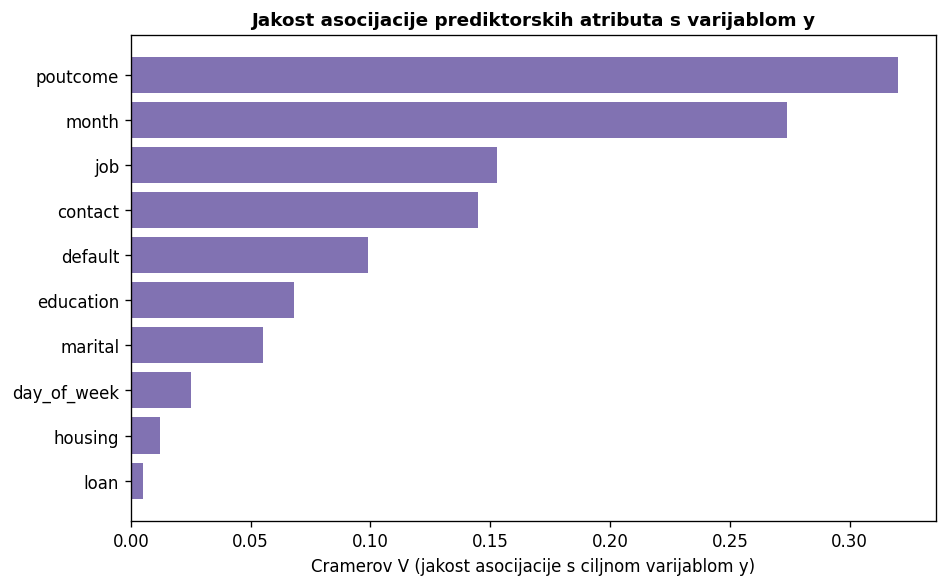

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
order = assoc_with_y_df.sort_values("Cramerov V")
ax.barh(order['Atribut'], order["Cramerov V"], color='#8172B2')
ax.set_xlabel("Cramerov V (jakost asocijacije s ciljnom varijablom y)")
ax.set_title("Jakost asocijacije prediktorskih atributa s varijablom y")
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/asocijacija_s_y.png')
plt.show()


Atributi s najjačom asocijacijom s y: ['poutcome', 'month']


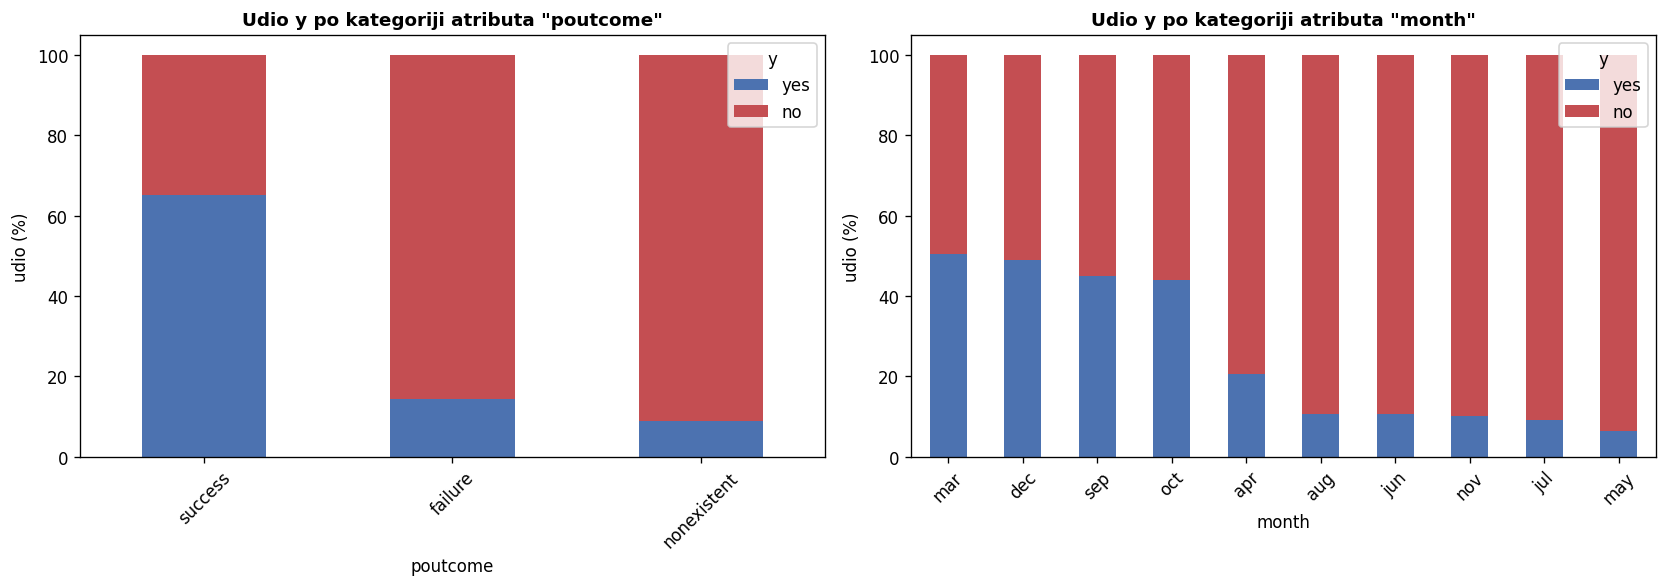

In [18]:
# Detaljniji prikaz za dva atributa s najjačom asocijacijom
top2 = assoc_with_y_df['Atribut'].head(2).tolist()
print("Atributi s najjačom asocijacijom s y:", top2)

fig, axes = plt.subplots(1, len(top2), figsize=(7 * len(top2), 5))
if len(top2) == 1:
    axes = [axes]

for ax, col in zip(axes, top2):
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct = ct.sort_values('yes', ascending=False)
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'])
    ax.set_ylabel('udio (%)')
    ax.set_title(f'Udio y po kategoriji atributa "{col}"')
    ax.legend(title='y')
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/y_po_top_atributima.png')
plt.show()


## 3.8 Matrica asocijacije među svim atributima (Cramérov V)

Osim odnosa prema `y`, korisno je provjeriti postoji li značajna asocijacija (redundancija) i
između samih prediktorskih atributa — ta informacija je relevantna za poglavlje 4 pri odabiru
strategije kodiranja (npr. ako su dva atributa jako asocirana, One-Hot kodiranje oba može uvesti
suvišnu, koreliranu informaciju u model temeljen na udaljenosti).

In [19]:
cols_all = list(df.columns)
n_cols = len(cols_all)
cramers_matrix = pd.DataFrame(np.ones((n_cols, n_cols)), index=cols_all, columns=cols_all)

for i in range(n_cols):
    for j in range(i + 1, n_cols):
        ct = pd.crosstab(df[cols_all[i]], df[cols_all[j]])
        v, _, _ = cramers_v(ct)
        cramers_matrix.iloc[i, j] = v
        cramers_matrix.iloc[j, i] = v

cramers_matrix = cramers_matrix.round(2)
cramers_matrix.to_csv(f'{REZULTATI_DIR}/3_8_cramers_v_matrica.csv')
cramers_matrix


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
job,1.00,0.18,0.36,0.15,0.02,0.02,0.13,0.11,0.02,0.10,0.15
marital,0.18,1.00,0.12,0.10,0.01,0.01,0.07,0.05,0.01,0.04,0.05
education,0.36,0.12,1.00,0.17,0.02,0.01,0.12,0.10,0.02,0.04,0.07
default,0.15,0.10,0.17,1.00,0.01,0.01,0.14,0.11,0.02,0.08,0.10
housing,0.02,0.01,0.02,0.01,1.00,0.71,0.08,0.06,0.02,0.02,0.01
loan,0.02,0.01,0.01,0.01,0.71,1.00,0.03,0.02,0.01,0.00,0.01
contact,0.13,0.07,0.12,0.14,0.08,0.03,1.00,0.61,0.06,0.24,0.14
month,0.11,0.05,0.10,0.11,0.06,0.02,0.61,1.00,0.07,0.24,0.27
day_of_week,0.02,0.01,0.02,0.02,0.02,0.01,0.06,0.07,1.00,0.02,0.03
poutcome,0.10,0.04,0.04,0.08,0.02,0.00,0.24,0.24,0.02,1.00,0.32


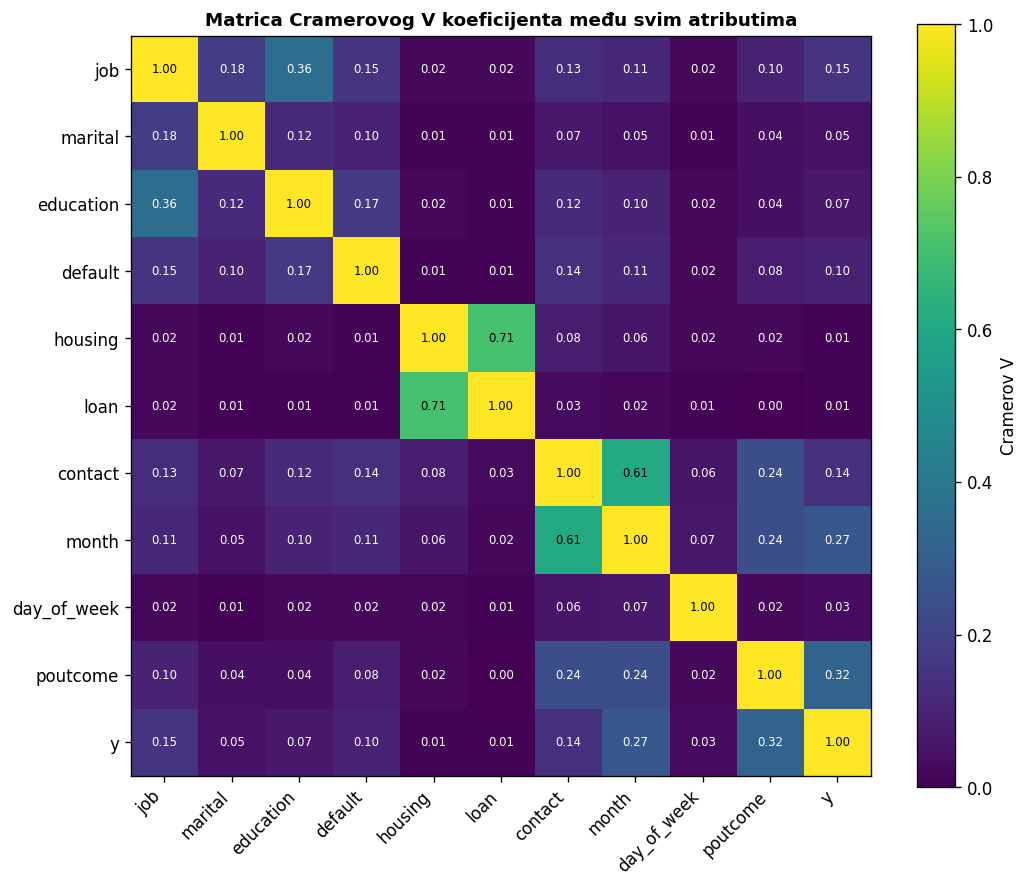

In [20]:
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cramers_matrix.values, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n_cols))
ax.set_xticklabels(cols_all, rotation=45, ha='right')
ax.set_yticks(range(n_cols))
ax.set_yticklabels(cols_all)

for i in range(n_cols):
    for j in range(n_cols):
        val = cramers_matrix.values[i, j]
        color = 'white' if val < 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=7)

ax.set_title('Matrica Cramerovog V koeficijenta među svim atributima')
fig.colorbar(im, ax=ax, label='Cramerov V')
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/cramers_v_matrica.png')
plt.show()


In [21]:
# Najjači parovi asocijacije (isključujući dijagonalu)
pairs = []
for i in range(n_cols):
    for j in range(i + 1, n_cols):
        pairs.append((cols_all[i], cols_all[j], cramers_matrix.iloc[i, j]))

pairs_df = pd.DataFrame(pairs, columns=['Atribut 1', 'Atribut 2', 'Cramerov V']).sort_values('Cramerov V', ascending=False)
pairs_df.head(10)


,Atribut 1,Atribut 2,Cramerov V
34,housing,loan,0.71
45,contact,month,0.61
1,job,education,0.36
54,poutcome,y,0.32
51,month,y,0.27
50,month,poutcome,0.24
47,contact,poutcome,0.24
0,job,marital,0.18
19,education,default,0.17
9,job,y,0.15


## 3.9 Rijetke kategorije

Kategorije s vrlo niskom relativnom učestalošću (< 1 % zapisa) posebno su zanimljive u kontekstu
detekcije anomalija — zapisi koji sadrže takve rijetke kombinacije kategorija prirodni su
kandidati za „netipične" (point anomaly) zapise, neovisno o vrijednosti ciljne varijable `y`.

In [22]:
RARE_THRESHOLD_PCT = 1.0

rare_categories = []
for col in predictor_cols:
    vc = df[col].value_counts()
    pct = vc / len(df) * 100
    for cat, p in pct.items():
        if p < RARE_THRESHOLD_PCT:
            rare_categories.append({
                'Atribut': col,
                'Kategorija': cat,
                'Broj': int(vc[cat]),
                'Postotak (%)': round(p, 3),
            })

rare_df = pd.DataFrame(rare_categories).sort_values('Postotak (%)').reset_index(drop=True)
rare_df.to_csv(f'{REZULTATI_DIR}/3_9_rijetke_kategorije.csv', index=False)
print(f"Broj rijetkih kategorija (< {RARE_THRESHOLD_PCT}%): {len(rare_df)}")
rare_df


Broj rijetkih kategorija (< 1.0%): 5


,Atribut,Kategorija,Broj,Postotak (%)
0,default,yes,3,0.007
1,education,illiterate,18,0.044
2,marital,unknown,80,0.194
3,month,dec,182,0.442
4,job,unknown,330,0.801


In [23]:
# Koliko zapisa sadrži barem jednu rijetku kategoriju u nekom od prediktorskih atributa?
rare_pairs = set(zip(rare_df['Atribut'], rare_df['Kategorija']))

def has_rare_category(row):
    return any((col, row[col]) in rare_pairs for col in predictor_cols)

rows_with_rare = df.apply(has_rare_category, axis=1)
n_rare_rows = int(rows_with_rare.sum())
print(f"Zapisa s barem jednom rijetkom kategorijom (< {RARE_THRESHOLD_PCT}%): "
      f"{n_rare_rows} ({n_rare_rows/len(df)*100:.2f}%)")


Zapisa s barem jednom rijetkom kategorijom (< 1.0%): 602 (1.46%)


## 3.10 Duplicirani zapisi

Budući da je skup podataka isključivo nominalan (11 atributa s ograničenim brojem kategorija),
očekuje se da će mnogi zapisi dijeliti identičnu kombinaciju vrijednosti čak i kad ne predstavljaju
istog klijenta. Ova provjera je važna jer modeli za detekciju anomalija temeljeni na gustoći
(npr. LOF) identične zapise tretiraju kao guste klastere, a ne kao anomalije.

In [24]:
n_unique_combinations = df.drop_duplicates().shape[0]
n_total = df.shape[0]
n_exact_duplicates = n_total - n_unique_combinations

print(f"Ukupno zapisa: {n_total}")
print(f"Broj jedinstvenih kombinacija svih 11 atributa: {n_unique_combinations}")
print(f"Broj zapisa koji dijele kombinaciju s barem jednim drugim zapisom (duplikati): {n_exact_duplicates} "
      f"({n_exact_duplicates/n_total*100:.2f}%)")

# Uključujući i prediktorske atribute bez y (jer y nije stvarna oznaka i ne bi trebala umjetno "razlikovati" zapise)
n_unique_predictors_only = df[predictor_cols].drop_duplicates().shape[0]
print(f"\nBroj jedinstvenih kombinacija bez atributa 'y': {n_unique_predictors_only}")


Ukupno zapisa: 41188
Broj jedinstvenih kombinacija svih 11 atributa: 19757
Broj zapisa koji dijele kombinaciju s barem jednim drugim zapisom (duplikati): 21431 (52.03%)

Broj jedinstvenih kombinacija bez atributa 'y': 18061


In [25]:
dup_counts = df.groupby(predictor_cols, observed=True).size().sort_values(ascending=False)
print("10 najčešće ponovljenih kombinacija prediktorskih atributa:")
dup_counts.head(10)


10 najčešće ponovljenih kombinacija prediktorskih atributa:


job     marital  education          default  housing  loan  contact   month  day_of_week  poutcome   
admin.  single   university.degree  no       yes      no    cellular  aug    thu          nonexistent    64
        married  university.degree  no       yes      no    cellular  aug    wed          nonexistent    62
                                                                             thu          nonexistent    54
                                                                             tue          nonexistent    51
                                             no       no    cellular  aug    thu          nonexistent    49
        single   university.degree  no       no       no    cellular  aug    wed          nonexistent    48
                                             yes      no    cellular  aug    mon          nonexistent    48
                                                                             wed          nonexistent    47
        married  university.degree

## 3.11 Sažetak ključnih nalaza

Sljedeća ćelija objedinjuje ključne brojke iz prethodnih odjeljaka (broj zapisa, distribucija
`y`, nedostajuće vrijednosti, kardinalnost atributa) u obliku pogodnom za izravno prenošenje u
LaTeX.

In [26]:
print("=" * 70)
print("SAŽETAK KLJUČNIH NALAZA - POGLAVLJE 3")
print("=" * 70)

print(f"\nBroj zapisa: {n_total}")

print(f"\nDistribucija y:")
print(f"  no  = {y_counts['no']} ({y_pct['no']}%)")
print(f"  yes = {y_counts['yes']} ({y_pct['yes']}%)")

print(f"\nUkupno kategorija kod 10 prediktorskih atributa: {n_predictors}")

print("\nNedostajuće vrijednosti ('unknown') po atributu:")
print(missing_df.to_string(index=False))

print("\nNajzastupljenije kategorije:")
for _, row in most_frequent_df.iterrows():
    if row['Atribut'] in ('job', 'month', 'poutcome'):
        print(f"  {row['Atribut']} = {row['Najzastupljenija kategorija']} ({row['Postotak (%)']}%)")


SAŽETAK KLJUČNIH NALAZA - POGLAVLJE 3

Broj zapisa: 41188

Distribucija y:
  no  = 36548 (88.73%)
  yes = 4640 (11.27%)

Ukupno kategorija kod 10 prediktorskih atributa: 53

Nedostajuće vrijednosti ('unknown') po atributu:
  Atribut  Broj "unknown"  Postotak (%)
  default            8597         20.87
education            1731          4.20
  housing             990          2.40
     loan             990          2.40
      job             330          0.80
  marital              80          0.19

Najzastupljenije kategorije:
  job = admin. (25.3%)
  month = may (33.43%)
  poutcome = nonexistent (86.34%)


### Ključni zaključci dublje analize (relevantni za poglavlje 4)

- **Entropija atributa** (odjeljak 3.6): atributi poput `poutcome`, `contact` i `default` imaju
  nisku normaliziranu entropiju (dominacija jedne kategorije), dok su `education` i `job`
  distribuiraniji — relevantno za očekivani učinak One-Hot kodiranja (nastaju rijetko aktivirane
  binarne značajke).
- **Asocijacija s `y`** (odjeljak 3.7): `poutcome`, `month` i `contact` pokazuju najjaču asocijaciju
  s ishodom kampanje prema Cramérovom V koeficijentu — korisno za kasniju raspravu o rezultatima
  modela u poglavlju 5/6.
- **Matrica Cramérovog V** (odjeljak 3.8): identificira potencijalno redundantne parove atributa,
  što izravno informira odluku o kodiranju u poglavlju 4.3.
- **Rijetke kategorije** (odjeljak 3.9) i **duplicirani zapisi** (odjeljak 3.10): pokazuju da velik
  udio zapisa dijeli identičnu kombinaciju kategorija, što je važan metodološki argument za
  poglavlje 4.2/4.4 — modeli temeljeni na gustoći/udaljenosti (LOF, One-Class SVM) na ovakvom
  isključivo nominalnom prostoru obilježja tretirat će identične kombinacije kao guste regije, a
  rijetke kombinacije kategorija kao prirodne kandidate za anomalije.

# 4. Metodologija istraživanja

Ovo poglavlje provodi cjelokupni postupak pripreme podataka te izrade i evaluacije modela za
nenadziranu detekciju anomalija: prikupljanje (4.1), čišćenje (4.2), pretprocesiranje/kodiranje
(4.3), izradu triju modela — Isolation Forest, Local Outlier Factor i One-Class SVM (4.4) — te
njihovu evaluaciju uz `y` kao proxy referencu (4.5).

## 4.1 Prikupljanje podataka

Skup podataka učitava se ARFF parserom `load_arff_nominal` (poglavlje 3.1); u nastavku se
potvrđuju dimenzije i tipovi podataka.

In [27]:
print(f"Skup podataka (učitan u odjeljku 3.1): {df.shape[0]} zapisa x {df.shape[1]} atributa")
print("\nTipovi podataka po stupcu:")
print(df.dtypes)

assert df.shape == (41188, 11), "Neočekivane dimenzije skupa podataka u odnosu na poglavlje 3."
assert (df.dtypes == 'category').all(), "Očekuje se da su svi atributi kategorički (category dtype)."
print("\nDimenzije i tipovi potvrđeni - u skladu s poglavljem 3.")


Skup podataka (učitan u odjeljku 3.1): 41188 zapisa x 11 atributa

Tipovi podataka po stupcu:
job            category
marital        category
education      category
default        category
housing        category
loan           category
contact        category
month          category
day_of_week    category
poutcome       category
y              category
dtype: object

Dimenzije i tipovi potvrđeni - u skladu s poglavljem 3.


## 4.2 Čišćenje podataka

Na temelju nalaza poglavlja 3 donose se dvije eksplicitne metodološke odluke o čišćenju podataka:

1. **Kategorija `unknown` se ne uklanja niti imputira.** Kod šest atributa (odjeljak 3.4) ona
   predstavlja nedostajuću vrijednost, no budući da 25,98 % zapisa ima barem jednu takvu vrijednost,
   njihovo bi brisanje uklonilo četvrtinu skupa podataka, a imputacija bi umjetno unijela informaciju
   koja ne postoji. `unknown` se stoga tretira kao zasebna, informativna kategorija.
2. **Duplicirani zapisi se ne uklanjaju.** Iako 52,03 % zapisa dijeli identičnu kombinaciju svih
   11 atributa s barem jednim drugim zapisom (odjeljak 3.10), svaki redak predstavlja zaseban
   telefonski kontakt u kampanji, a ne pogrešku unosa — isti ili različiti klijenti mogu imati
   identičan kategorički profil (dob, zanimanje itd. nisu ni zabilježeni u ovoj inačici skupa).
   Uklanjanje takvih zapisa umjetno bi smanjilo skup i moglo ukloniti legitimne, potencijalno
   anomalne obrasce koje modeli u odjeljku 4.4 trebaju otkriti.

Skup stoga ostaje nepromijenjen u odnosu na odjeljak 4.1.

In [28]:
n_before = df.shape[0]

# Provjera da nema "pravih" nedostajućih vrijednosti (NaN) izvan kategorije 'unknown' (potvrđeno već u 3.1)
assert df.isna().sum().sum() == 0, "Pronađene su prave NaN vrijednosti izvan kategorije 'unknown'."

# Odluka 1: kategorija 'unknown' se NE uklanja niti imputira - zadržava se kao zasebna kategorija.
# Odluka 2: duplicirani zapisi se NE uklanjaju - svaki redak je zaseban zapis o kontaktu.
# (obje odluke obrazložene tekstualno iznad; skup se u ovom koraku ne mijenja)
df_clean = df.copy()

n_after = df_clean.shape[0]
print(f"Broj zapisa prije čišćenja: {n_before}")
print(f"Broj zapisa nakon čišćenja: {n_after}")
assert n_before == n_after, "Broj zapisa se promijenio, iako čišćenje ne bi trebalo brisati zapise."
print("Potvrđeno: čišćenje nije promijenilo broj zapisa (nema brisanja/imputacije).")


Broj zapisa prije čišćenja: 41188
Broj zapisa nakon čišćenja: 41188
Potvrđeno: čišćenje nije promijenilo broj zapisa (nema brisanja/imputacije).


## 4.3 Pretprocesiranje podataka

### 4.3.1 Label Encoding — problem kod čisto nominalnih atributa

Label Encoding svakoj kategoriji dodjeljuje cjelobrojnu oznaku (0, 1, 2, ...), obično prema
abecednom redoslijedu. Za atribute bez prirodnog poretka (npr. `job`, `marital`) takvo kodiranje
modelu implicitno sugerira linearni odnos i udaljenost među kategorijama koja u stvarnosti ne
postoji (npr. da je `blue-collar` „bliži" atributu `admin.` nego `unemployed`, samo zato što su im
dodijeljeni susjedni brojevi) — to je osobito problematično za algoritme temeljene na udaljenosti ili
gustoći poput LOF-a i One-Class SVM-a (poglavlje 2.4).

In [29]:
from sklearn.preprocessing import LabelEncoder

# Ilustracija problema: Label Encoding dodjeljuje proizvoljne, abecedno poredane cjelobrojne oznake
label_encoding_demo = {}
for col in ['job', 'marital']:
    le = LabelEncoder()
    le.fit(df_clean[col])
    mapping = dict(zip(le.classes_, range(len(le.classes_))))
    label_encoding_demo[col] = mapping
    print(f"Label Encoding za '{col}' (abecedni poredak, BEZ stvarnog značenja):")
    print(mapping)
    print()


Label Encoding za 'job' (abecedni poredak, BEZ stvarnog značenja):
{'admin.': 0, 'blue-collar': 1, 'entrepreneur': 2, 'housemaid': 3, 'management': 4, 'retired': 5, 'self-employed': 6, 'services': 7, 'student': 8, 'technician': 9, 'unemployed': 10, 'unknown': 11}

Label Encoding za 'marital' (abecedni poredak, BEZ stvarnog značenja):
{'divorced': 0, 'married': 1, 'single': 2, 'unknown': 3}



### 4.3.2 Ordinalno kodiranje atributa `education` — iznimka

Za razliku od `job` ili `marital`, atribut `education` ima prirodan, smislen poredak razina
obrazovanja: `illiterate` < `basic.4y` < `basic.6y` < `basic.9y` < `high.school` <
`professional.course` < `university.degree`. Za taj je atribut stoga ordinalno kodiranje
metodološki opravdanije od Label Encodinga, jer dodijeljeni brojevi doista odražavaju rastući
poredak razine obrazovanja. Kategorija `unknown` ne pripada ovom poretku pa joj se, kao
pragmatično rješenje, dodjeljuje zasebna, najviša oznaka (izvan ljestvice), a u glavnoj
One-Hot reprezentaciji (4.3.3) svejedno se kodira kao zasebna binarna značajka.

In [30]:
EDUCATION_ORDER = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school',
                    'professional.course', 'university.degree', 'unknown']
education_ordinal_map = {cat: i for i, cat in enumerate(EDUCATION_ORDER)}

df_clean['education_ordinal'] = df_clean['education'].map(education_ordinal_map).astype(int)

print("Ordinalno kodiranje atributa 'education':")
for cat, code in education_ordinal_map.items():
    print(f"  {cat} -> {code}")

print("\nPrimjer (prvih 5 zapisa):")
df_clean[['education', 'education_ordinal']].head()


Ordinalno kodiranje atributa 'education':
  illiterate -> 0
  basic.4y -> 1
  basic.6y -> 2
  basic.9y -> 3
  high.school -> 4
  professional.course -> 5
  university.degree -> 6
  unknown -> 7

Primjer (prvih 5 zapisa):


,education,education_ordinal
0,basic.4y,1
1,high.school,4
2,high.school,4
3,basic.6y,2
4,high.school,4


### 4.3.3 One-Hot Encoding — glavna strategija kodiranja

Za sve ostale nominalne atribute (i, radi konzistentnosti reprezentacije, i za `education`) koristi
se One-Hot Encoding: svaka kategorija postaje zasebna binarna značajka (0/1), čime se izbjegava
umjetno uvođenje poretka ili udaljenosti među kategorijama. Cijena je veća dimenzionalnost prostora
značajki, no budući da skup sadrži samo 53 kategorije raspoređene na 10 prediktorskih atributa
(odjeljak 3.2), rezultirajuća matrica ostaje niske dimenzionalnosti i praktično upotrebljiva za sva
tri algoritma iz poglavlja 2.4. Ciljna varijabla `y` kodira se zasebno (`y_binary`) i **ne**
uključuje se u ulazne značajke za modele.

In [31]:
X = pd.get_dummies(df_clean[predictor_cols], columns=predictor_cols)
X = X.astype(int)

y_binary = (df_clean['y'] == 'yes').astype(int)
y_binary.name = 'y_binary'

print(f"Oblik matrice značajki nakon One-Hot kodiranja: {X.shape}")
assert X.shape == (41188, 53), "Broj binarnih stupaca nakon One-Hot kodiranja ne odgovara očekivanih 53 (poglavlje 3.2)."
print("Potvrđeno: 41.188 x 53, u skladu s brojem kategorija utvrđenim u poglavlju 3.2.")

print(f"\nDistribucija y_binary (1 = 'yes' / proxy-anomalija, 0 = 'no' / normalno):")
print(y_binary.value_counts())

print("\nPrimjer jednog kodiranog retka (prvi zapis):")
X.iloc[[0]]


Oblik matrice značajki nakon One-Hot kodiranja: (41188, 53)
Potvrđeno: 41.188 x 53, u skladu s brojem kategorija utvrđenim u poglavlju 3.2.

Distribucija y_binary (1 = 'yes' / proxy-anomalija, 0 = 'no' / normalno):
y_binary
0    36548
1     4640
Name: count, dtype: int64

Primjer jednog kodiranog retka (prvi zapis):


,job_housemaid,job_services,job_admin.,job_blue-collar,job_technician,job_retired,job_management,job_unemployed,job_self-employed,job_unknown,job_entrepreneur,job_student,marital_married,marital_single,marital_divorced,marital_unknown,education_basic.4y,education_high.school,education_basic.6y,education_basic.9y,education_professional.course,education_unknown,education_university.degree,education_illiterate,default_no,default_unknown,default_yes,housing_no,housing_yes,housing_unknown,loan_no,loan_yes,loan_unknown,contact_telephone,contact_cellular,month_may,month_jun,month_jul,month_aug,month_oct,month_nov,month_dec,month_mar,month_apr,month_sep,day_of_week_mon,day_of_week_tue,day_of_week_wed,day_of_week_thu,day_of_week_fri,poutcome_nonexistent,poutcome_failure,poutcome_success
0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0


## 4.4 Izrada modela

Sva tri modela treniraju se **nenadzirano**, bez train/test podjele — `y` se ne koristi za
treniranje, nego isključivo naknadno (4.5) kao proxy referenca za evaluaciju. Parametar udjela
anomalija (`contamination`/`nu`) kod sva tri algoritma postavljen je na stvarni udio manjinske
klase `y = yes`: **0,1127** (11,27 %, odjeljak 3.5), radi metodološke dosljednosti.

**Isolation Forest** ima linearnu vremensku složenost (poglavlje 2.4.1) pa se trenira na punom
skupu (41.188 x 53). **LOF** i **One-Class SVM**, prema tablici prednosti/nedostataka u poglavlju
2.4.5, imaju slabu skalabilnost (LOF zbog izračuna gustoće po susjedstvu, One-Class SVM zbog RBF
jezgre kvadratne/kubne složenosti) — na punom skupu od 41.188 zapisa njihovo treniranje nije
praktično izvedivo, pa se za oba modela koristi slučajni poduzorak od 10.000 zapisa
(`random_state=42`), što se ovdje eksplicitno navodi kao praktično ograničenje.

In [32]:
import time
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

CONTAMINATION = 0.1127  # stvarni udio manjinske klase (y = 'yes'), odjeljak 3.5
RANDOM_STATE = 42
SUBSAMPLE_SIZE = 10000

X_values = X.values

# --- Slučajni poduzorak za LOF i One-Class SVM (praktično ograničenje, vidi tekst iznad) ---
rng = np.random.RandomState(RANDOM_STATE)
sub_idx = rng.choice(X_values.shape[0], size=SUBSAMPLE_SIZE, replace=False)
X_sub = X_values[sub_idx]
y_sub = y_binary.values[sub_idx]

print(f"Poduzorak za LOF i One-Class SVM: {X_sub.shape[0]} zapisa "
      f"(slučajni odabir bez ponavljanja, random_state={RANDOM_STATE})")
sub_pos = int((y_sub == 1).sum())
print(f"Distribucija y u poduzorku: yes={sub_pos} ({sub_pos/len(y_sub)*100:.2f}%), "
      f"no={len(y_sub)-sub_pos} ({(len(y_sub)-sub_pos)/len(y_sub)*100:.2f}%)")


Poduzorak za LOF i One-Class SVM: 10000 zapisa (slučajni odabir bez ponavljanja, random_state=42)
Distribucija y u poduzorku: yes=1128 (11.28%), no=8872 (88.72%)


In [33]:
# --- Isolation Forest: treniran na PUNOM skupu (41.188 x 53) ---
t0 = time.time()
iso_forest = IsolationForest(n_estimators=100, contamination=CONTAMINATION,
                              random_state=RANDOM_STATE, n_jobs=-1)
iso_forest.fit(X_values)
t_iso = time.time() - t0
print(f"Isolation Forest: treniran na {X_values.shape[0]} zapisa (puni skup), "
      f"vrijeme treniranja = {t_iso:.2f} s")


Isolation Forest: treniran na 41188 zapisa (puni skup), vrijeme treniranja = 0.55 s


In [34]:
# --- Local Outlier Factor: treniran/evaluiran na poduzorku (10.000 x 53) ---
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION, novelty=False)
lof_pred_sub = lof.fit_predict(X_sub)          # -1 = anomalija, 1 = normalno
lof_scores_sub = -lof.negative_outlier_factor_  # veći rezultat = anomalniji zapis
t_lof = time.time() - t0
print(f"LOF: treniran/evaluiran na poduzorku od {X_sub.shape[0]} zapisa "
      f"(puni skup od {X_values.shape[0]} zapisa praktično neizvediv - vidi 2.4.5), "
      f"vrijeme = {t_lof:.2f} s")


LOF: treniran/evaluiran na poduzorku od 10000 zapisa (puni skup od 41188 zapisa praktično neizvediv - vidi 2.4.5), vrijeme = 2.27 s


In [35]:
# --- One-Class SVM: treniran/evaluiran na poduzorku (10.000 x 53) ---
t0 = time.time()
ocsvm = OneClassSVM(nu=CONTAMINATION, kernel='rbf', gamma='scale')
ocsvm.fit(X_sub)
ocsvm_pred_sub = ocsvm.predict(X_sub)                 # -1 = anomalija, 1 = normalno
ocsvm_scores_sub = -ocsvm.decision_function(X_sub)    # veći rezultat = anomalniji zapis
t_ocsvm = time.time() - t0
print(f"One-Class SVM: treniran/evaluiran na poduzorku od {X_sub.shape[0]} zapisa "
      f"(RBF jezgra, puni skup od {X_values.shape[0]} zapisa praktično neizvediv - vidi 2.4.5), "
      f"vrijeme = {t_ocsvm:.2f} s")


One-Class SVM: treniran/evaluiran na poduzorku od 10000 zapisa (RBF jezgra, puni skup od 41188 zapisa praktično neizvediv - vidi 2.4.5), vrijeme = 2.69 s


In [36]:
# Isolation Forest se dodatno primjenjuje i na isti poduzorak (10.000 zapisa) radi izravne,
# poštene usporedbe sve tri metode na identičnom skupu u odjeljku 4.5
iso_pred_sub = iso_forest.predict(X_sub)
iso_scores_sub = -iso_forest.decision_function(X_sub)

training_summary = pd.DataFrame([
    {'Model': 'Isolation Forest', 'Veličina skupa za treniranje': X_values.shape[0],
     'Vrijeme treniranja (s)': round(t_iso, 3), 'Napomena': 'puni skup'},
    {'Model': 'Local Outlier Factor', 'Veličina skupa za treniranje': X_sub.shape[0],
     'Vrijeme treniranja (s)': round(t_lof, 3), 'Napomena': 'poduzorak (praktično ograničenje)'},
    {'Model': 'One-Class SVM', 'Veličina skupa za treniranje': X_sub.shape[0],
     'Vrijeme treniranja (s)': round(t_ocsvm, 3), 'Napomena': 'poduzorak (praktično ograničenje)'},
])
training_summary.to_csv(f'{REZULTATI_DIR}/4_4_vrijeme_treniranja.csv', index=False)
training_summary


,Model,Veličina skupa za treniranje,Vrijeme treniranja (s),Napomena
0,Isolation Forest,41188,0.545,puni skup
1,Local Outlier Factor,10000,2.274,poduzorak (praktično ograničenje)
2,One-Class SVM,10000,2.695,poduzorak (praktično ograničenje)


## 4.5 Evaluacija modela

Kao proxy referenca koristi se ciljna varijabla `y` (`yes` = 1 = „anomalija", `no` = 0 =
„normalno") — **napomena**: `y` formalno bilježi marketinški ishod, a ne izvornu oznaku anomalije,
pa se rezultati u nastavku moraju čitati kao orijentacijski, a ne kao apsolutna mjera točnosti
detekcije anomalija.

Glavna usporedba sva tri modela provodi se na **istom poduzorku od 10.000 zapisa** (odjeljak 4.4),
kako bi metrike bile izravno usporedive. Za svaki model izračunavaju se matrica zabune, Precision,
Recall, F1-mjera, ROC AUC i PR AUC (Precision-Recall AUC), a potonji je posebno relevantan zbog
neravnoteže razreda (odjeljak 3.5) — vidi literaturu o evaluaciji na nebalansiranim skupovima
(He i Garcia, 2009; Saito i Rehmsmeier, 2015).

In [37]:
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, roc_curve, precision_recall_curve)

def eval_model(y_true, pred_labels_pm1, anomaly_scores):
    """pred_labels_pm1: sklearn konvencija (-1 = anomalija, 1 = normalno).
    anomaly_scores: veći rezultat = anomalniji zapis (za ROC/PR krivulje)."""
    pred_bin = (pred_labels_pm1 == -1).astype(int)  # 1 = anomalija, 0 = normalno
    cm = confusion_matrix(y_true, pred_bin, labels=[0, 1])
    return {
        'cm': cm,
        'precision': precision_score(y_true, pred_bin, zero_division=0),
        'recall': recall_score(y_true, pred_bin, zero_division=0),
        'f1': f1_score(y_true, pred_bin, zero_division=0),
        'roc_auc': roc_auc_score(y_true, anomaly_scores),
        'pr_auc': average_precision_score(y_true, anomaly_scores),
        'pred_bin': pred_bin,
    }

MODEL_COLORS = {
    'Isolation Forest': '#4C72B0',
    'LOF': '#DD8452',
    'One-Class SVM': '#55A868',
}

results = {
    'Isolation Forest': eval_model(y_sub, iso_pred_sub, iso_scores_sub),
    'LOF': eval_model(y_sub, lof_pred_sub, lof_scores_sub),
    'One-Class SVM': eval_model(y_sub, ocsvm_pred_sub, ocsvm_scores_sub),
}

eval_summary = pd.DataFrame({
    name: {
        'Precision': round(r['precision'], 3),
        'Recall': round(r['recall'], 3),
        'F1-mjera': round(r['f1'], 3),
        'ROC AUC': round(r['roc_auc'], 3),
        'PR AUC': round(r['pr_auc'], 3),
    } for name, r in results.items()
}).T
eval_summary.to_csv(f'{REZULTATI_DIR}/4_5_evaluacija_modela.csv')
eval_summary


,Precision,Recall,F1-mjera,ROC AUC,PR AUC
Isolation Forest,0.161,0.155,0.158,0.566,0.143
LOF,0.239,0.238,0.239,0.634,0.193
One-Class SVM,0.214,0.214,0.214,0.577,0.165


In [38]:
# Matrice zabune (redak = stvarna vrijednost y, stupac = predikcija modela; 0 = normalno, 1 = anomalija)
for name, r in results.items():
    cm = r['cm']
    print(f"\n--- {name} ---")
    cm_df = pd.DataFrame(cm, index=['stvarno: no (0)', 'stvarno: yes (1)'],
                          columns=['predikcija: normalno (0)', 'predikcija: anomalija (1)'])
    print(cm_df)
    cm_df.to_csv(f'{REZULTATI_DIR}/4_5_matrica_zabune_{name.lower().replace(" ", "_").replace("-", "_")}.csv')



--- Isolation Forest ---
                  predikcija: normalno (0)  predikcija: anomalija (1)
stvarno: no (0)                       7960                        912
stvarno: yes (1)                       953                        175



--- LOF ---
                  predikcija: normalno (0)  predikcija: anomalija (1)
stvarno: no (0)                       8014                        858
stvarno: yes (1)                       859                        269

--- One-Class SVM ---
                  predikcija: normalno (0)  predikcija: anomalija (1)
stvarno: no (0)                       7986                        886
stvarno: yes (1)                       887                        241


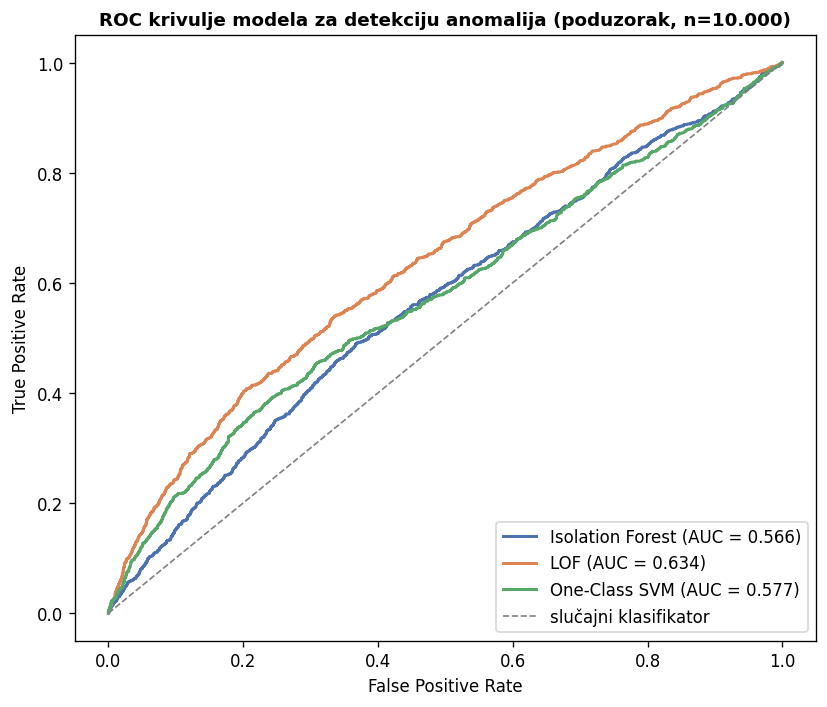

In [39]:
scores_by_model = {
    'Isolation Forest': iso_scores_sub,
    'LOF': lof_scores_sub,
    'One-Class SVM': ocsvm_scores_sub,
}

fig, ax = plt.subplots(figsize=(7, 6))
for name, scores in scores_by_model.items():
    fpr, tpr, _ = roc_curve(y_sub, scores)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['roc_auc']:.3f})",
            color=MODEL_COLORS[name], linewidth=1.8)
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='slučajni klasifikator')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC krivulje modela za detekciju anomalija (poduzorak, n=10.000)')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/roc_krivulje.png')
plt.show()


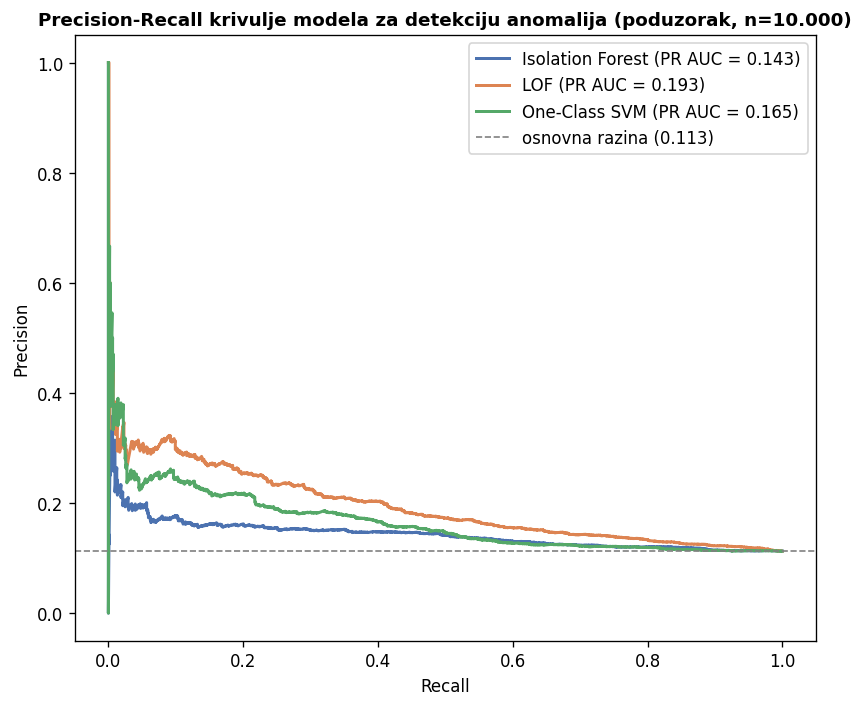

In [40]:
baseline_precision = y_sub.mean()  # udio pozitivne klase u poduzorku

fig, ax = plt.subplots(figsize=(7, 6))
for name, scores in scores_by_model.items():
    precision, recall, _ = precision_recall_curve(y_sub, scores)
    ax.plot(recall, precision, label=f"{name} (PR AUC = {results[name]['pr_auc']:.3f})",
            color=MODEL_COLORS[name], linewidth=1.8)
ax.axhline(baseline_precision, linestyle='--', color='gray', linewidth=1,
           label=f'osnovna razina ({baseline_precision:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall krivulje modela za detekciju anomalija (poduzorak, n=10.000)')
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/pr_krivulje.png')
plt.show()


### 4.5.1 Dodatna evaluacija: Isolation Forest na punom skupu podataka

Budući da je Isolation Forest jedini od tri modela treniran na punom skupu (41.188 zapisa,
odjeljak 4.4), ovdje se dodatno prikazuje njegova evaluacija na tom punom skupu — kao ilustracija
prakse i skalabilnosti algoritma, odvojeno od glavne, izravne usporedbe sva tri modela na poduzorku.

In [41]:
iso_pred_full = iso_forest.predict(X_values)
iso_scores_full = -iso_forest.decision_function(X_values)
iso_full_eval = eval_model(y_binary.values, iso_pred_full, iso_scores_full)

print("Isolation Forest - evaluacija na PUNOM skupu (41.188 zapisa):")
print(f"  Precision = {iso_full_eval['precision']:.3f}")
print(f"  Recall    = {iso_full_eval['recall']:.3f}")
print(f"  F1-mjera  = {iso_full_eval['f1']:.3f}")
print(f"  ROC AUC   = {iso_full_eval['roc_auc']:.3f}")
print(f"  PR AUC    = {iso_full_eval['pr_auc']:.3f}")

iso_full_cm_df = pd.DataFrame(iso_full_eval['cm'],
                               index=['stvarno: no (0)', 'stvarno: yes (1)'],
                               columns=['predikcija: normalno (0)', 'predikcija: anomalija (1)'])
print("\nMatrica zabune (puni skup):")
print(iso_full_cm_df)
iso_full_cm_df.to_csv(f'{REZULTATI_DIR}/4_5_matrica_zabune_isolation_forest_puni_skup.csv')

iso_full_summary = pd.DataFrame([{
    'Precision': round(iso_full_eval['precision'], 3),
    'Recall': round(iso_full_eval['recall'], 3),
    'F1-mjera': round(iso_full_eval['f1'], 3),
    'ROC AUC': round(iso_full_eval['roc_auc'], 3),
    'PR AUC': round(iso_full_eval['pr_auc'], 3),
}], index=['Isolation Forest (puni skup, n=41.188)'])
iso_full_summary.to_csv(f'{REZULTATI_DIR}/4_5_evaluacija_isolation_forest_puni_skup.csv')
iso_full_summary


Isolation Forest - evaluacija na PUNOM skupu (41.188 zapisa):
  Precision = 0.163
  Recall    = 0.163
  F1-mjera  = 0.163
  ROC AUC   = 0.565
  PR AUC    = 0.143

Matrica zabune (puni skup):
                  predikcija: normalno (0)  predikcija: anomalija (1)
stvarno: no (0)                      32664                       3884
stvarno: yes (1)                      3882                        758


,Precision,Recall,F1-mjera,ROC AUC,PR AUC
"Isolation Forest (puni skup, n=41.188)",0.163,0.163,0.163,0.565,0.143


## 4.6 Sažetak ključnih nalaza poglavlja 4

Sljedeća ćelija objedinjuje ključne brojke iz poglavlja 4 (dimenzije nakon kodiranja, vrijeme
treniranja, metrike evaluacije) u obliku pogodnom za izravno prenošenje u LaTeX (poglavlja 4 i 5).

In [42]:
print("=" * 70)
print("SAŽETAK KLJUČNIH NALAZA - POGLAVLJE 4")
print("=" * 70)

print(f"\nOblik matrice značajki nakon One-Hot kodiranja: {X.shape}")
print(f"contamination / nu = {CONTAMINATION}")
print(f"Veličina poduzorka za LOF i One-Class SVM: {SUBSAMPLE_SIZE} (random_state={RANDOM_STATE})")

print("\nVrijeme treniranja:")
print(training_summary.to_string(index=False))

print("\nEvaluacija na poduzorku (n=10.000, glavna usporedba):")
print(eval_summary.to_string())

print("\nEvaluacija Isolation Forest na punom skupu (n=41.188, dodatni rezultat):")
print(iso_full_summary.to_string())

print("\nPutanje spremljenih slika:")
for fname in ['roc_krivulje.png', 'pr_krivulje.png']:
    print(f"  {SLIKE_DIR}/{fname}")


SAŽETAK KLJUČNIH NALAZA - POGLAVLJE 4

Oblik matrice značajki nakon One-Hot kodiranja: (41188, 53)
contamination / nu = 0.1127
Veličina poduzorka za LOF i One-Class SVM: 10000 (random_state=42)

Vrijeme treniranja:
               Model  Veličina skupa za treniranje  Vrijeme treniranja (s)                          Napomena
    Isolation Forest                         41188                   0.545                         puni skup
Local Outlier Factor                         10000                   2.274 poduzorak (praktično ograničenje)
       One-Class SVM                         10000                   2.695 poduzorak (praktično ograničenje)

Evaluacija na poduzorku (n=10.000, glavna usporedba):
                  Precision  Recall  F1-mjera  ROC AUC  PR AUC
Isolation Forest      0.161   0.155     0.158    0.566   0.143
LOF                   0.239   0.238     0.239    0.634   0.193
One-Class SVM         0.214   0.214     0.214    0.577   0.165

Evaluacija Isolation Forest na punom skup

# 5. Rezultati istraživanja

Ovo poglavlje dublje analizira rezultate triju modela za detekciju anomalija: objedinjenom
vizualnom usporedbom svih metrika odjednom (5.1), analizom slaganja triju modela oko toga koji su
zapisi anomalni (5.2), karakterizacijom onoga što otkrivene anomalije čini neobičnima (5.3), te
provjerom osjetljivosti rezultata na odabir parametra kontaminacije (5.4). Sve analize koriste isti
poduzorak od 10.000 zapisa i iste istrenirane modele opisane u poglavlju 4.

## 5.1 Objedinjeni pregled rezultata

Tablica \ref{tab:evaluacija-modela} (odjeljak 4.5) prikazuje pet metrika za svaki model zasebno.
Kako bi se cjelokupni obrazac uočio na prvi pogled, u nastavku se iste vrijednosti prikazuju kao
grupirani stupčasti graf — svih pet metrika i sva tri modela na jednoj slici.

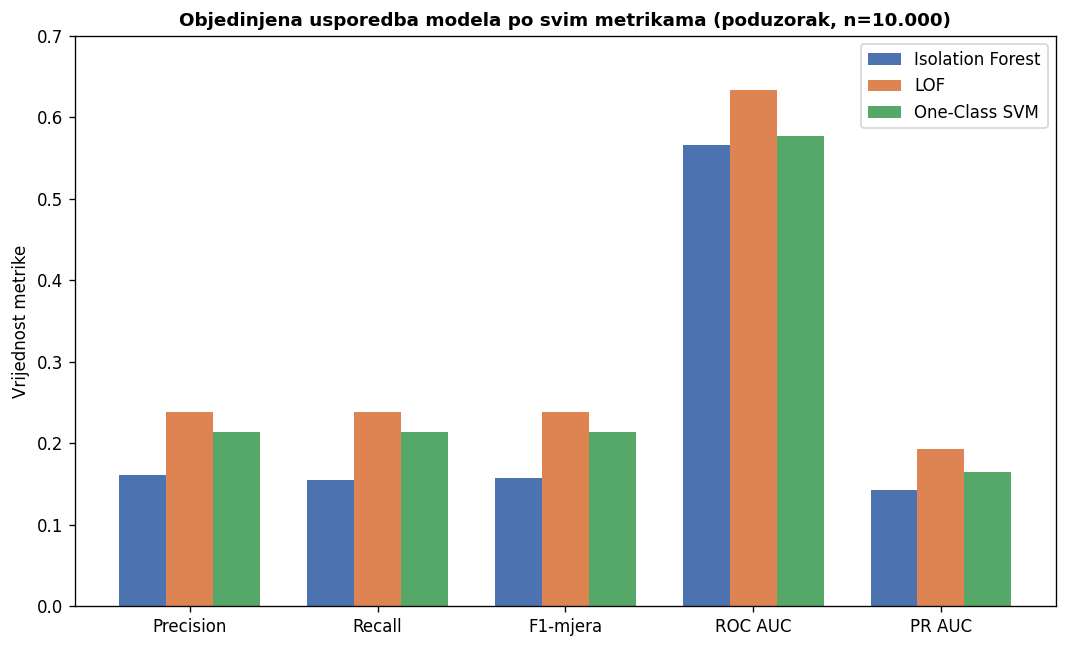

In [43]:
metrics = ['Precision', 'Recall', 'F1-mjera', 'ROC AUC', 'PR AUC']
model_names = list(eval_summary.index)

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, name in enumerate(model_names):
    vals = eval_summary.loc[name, metrics].values.astype(float)
    ax.bar(x + (i - 1) * width, vals, width, label=name, color=MODEL_COLORS[name])

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Vrijednost metrike')
ax.set_title('Objedinjena usporedba modela po svim metrikama (poduzorak, n=10.000)')
ax.legend()
ax.set_ylim(0, 0.7)
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/usporedba_metrika.png')
plt.show()


## 5.2 Preklapanje otkrivenih anomalija između modela

Poglavlje 4.5 pokazuje koliko dobro svaki model pojedinačno pogađa proxy anomalije (`y`), no ne i
slažu li se tri modela međusobno oko toga koji su zapisi anomalni. Za sva tri modela (na istom
poduzorku od 10.000 zapisa) uzimaju se skupovi zapisa koje je svaki model označio kao anomaliju
(sklearn konvencija: predikcija -1), te se računa njihovo preklapanje i Jaccardov indeks sličnosti
za svaki par modela ($J(A,B) = |A \cap B| / |A \cup B|$).

In [44]:
anomaly_sets = {
    'Isolation Forest': set(np.where(iso_pred_sub == -1)[0]),
    'LOF': set(np.where(lof_pred_sub == -1)[0]),
    'One-Class SVM': set(np.where(ocsvm_pred_sub == -1)[0]),
}
for name, s in anomaly_sets.items():
    print(f"{name}: {len(s)} zapisa označeno kao anomalija ({len(s) / SUBSAMPLE_SIZE * 100:.2f}%)")

A, B, C = anomaly_sets['Isolation Forest'], anomaly_sets['LOF'], anomaly_sets['One-Class SVM']

overlap_summary = pd.DataFrame([
    {'Skupina': 'Samo Isolation Forest', 'Broj zapisa': len(A - B - C)},
    {'Skupina': 'Samo LOF', 'Broj zapisa': len(B - A - C)},
    {'Skupina': 'Samo One-Class SVM', 'Broj zapisa': len(C - A - B)},
    {'Skupina': 'Isolation Forest i LOF (bez OCSVM)', 'Broj zapisa': len((A & B) - C)},
    {'Skupina': 'Isolation Forest i One-Class SVM (bez LOF)', 'Broj zapisa': len((A & C) - B)},
    {'Skupina': 'LOF i One-Class SVM (bez Isolation Forest)', 'Broj zapisa': len((B & C) - A)},
    {'Skupina': 'Sva tri modela', 'Broj zapisa': len(A & B & C)},
    {'Skupina': 'Nijedan model (normalno prema sva tri)', 'Broj zapisa': SUBSAMPLE_SIZE - len(A | B | C)},
])
overlap_summary.to_csv(f'{REZULTATI_DIR}/5_2_preklapanje_modela.csv', index=False)
overlap_summary


Isolation Forest: 1087 zapisa označeno kao anomalija (10.87%)
LOF: 1127 zapisa označeno kao anomalija (11.27%)
One-Class SVM: 1127 zapisa označeno kao anomalija (11.27%)


,Skupina,Broj zapisa
0,Samo Isolation Forest,257
1,Samo LOF,630
2,Samo One-Class SVM,172
3,Isolation Forest i LOF (bez OCSVM),20
4,Isolation Forest i One-Class SVM (bez LOF),478
5,LOF i One-Class SVM (bez Isolation Forest),145
6,Sva tri modela,332
7,Nijedan model (normalno prema sva tri),7966


In [45]:
def jaccard(s1, s2):
    return len(s1 & s2) / len(s1 | s2)

jaccard_summary = pd.DataFrame([
    {'Par modela': 'Isolation Forest - LOF', 'Jaccardov indeks': round(jaccard(A, B), 3)},
    {'Par modela': 'Isolation Forest - One-Class SVM', 'Jaccardov indeks': round(jaccard(A, C), 3)},
    {'Par modela': 'LOF - One-Class SVM', 'Jaccardov indeks': round(jaccard(B, C), 3)},
])
jaccard_summary.to_csv(f'{REZULTATI_DIR}/5_2_jaccard_indeksi.csv', index=False)

# Očekivano preklapanje pri potpuno nasumičnom označavanju (kontrolna vrijednost)
p = CONTAMINATION
expected_random_jaccard = (p * p) / (p + p - p * p)
print(f"Očekivani Jaccardov indeks pri nezavisnom, nasumičnom označavanju istog udjela ({p}): "
      f"{expected_random_jaccard:.3f}")

jaccard_summary


Očekivani Jaccardov indeks pri nezavisnom, nasumičnom označavanju istog udjela (0.1127): 0.060


,Par modela,Jaccardov indeks
0,Isolation Forest - LOF,0.189
1,Isolation Forest - One-Class SVM,0.577
2,LOF - One-Class SVM,0.268


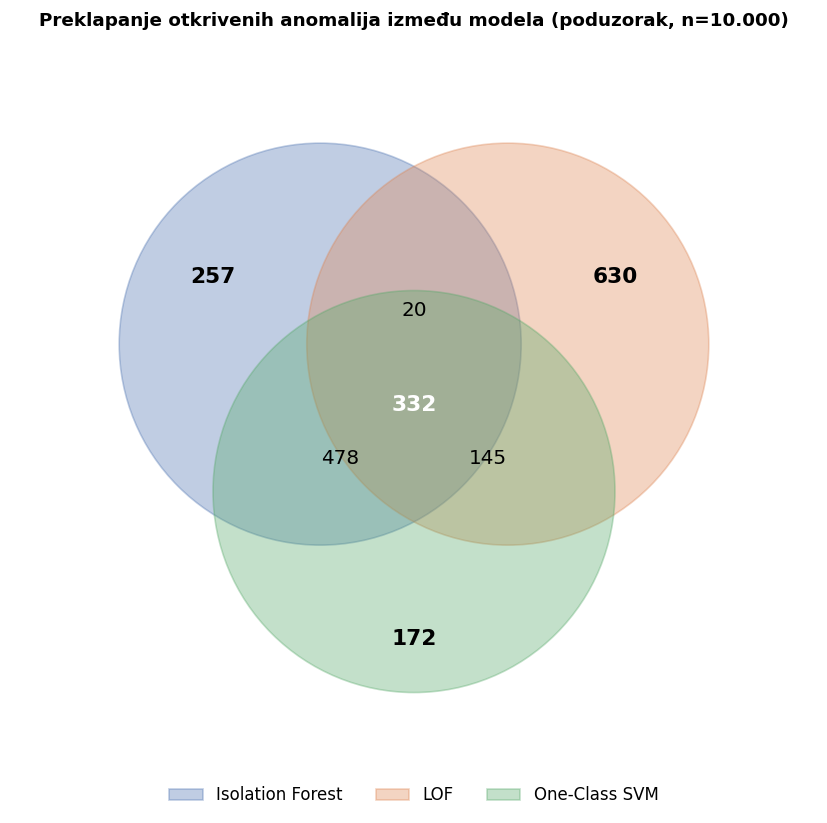

In [46]:
# Shematski (ne strogo proporcionalan) Vennov dijagram s tri kruga -- prikazuje stvarne brojke
# iz tablice preklapanja; egzaktne vrijednosti dane su u tab:preklapanje-modela.
fig, ax = plt.subplots(figsize=(7, 7))

centers = {'Isolation Forest': (-0.7, 0.5), 'LOF': (0.7, 0.5), 'One-Class SVM': (0.0, -0.6)}
radius = 1.5
for name, (cx, cy) in centers.items():
    circle = plt.Circle((cx, cy), radius, alpha=0.35, color=MODEL_COLORS[name], label=name)
    ax.add_patch(circle)

label_only = {'Isolation Forest': (-1.5, 1.0), 'LOF': (1.5, 1.0), 'One-Class SVM': (0.0, -1.7)}
for name, pos in label_only.items():
    key = {'Isolation Forest': 'Samo Isolation Forest', 'LOF': 'Samo LOF',
           'One-Class SVM': 'Samo One-Class SVM'}[name]
    val = int(overlap_summary.loc[overlap_summary['Skupina'] == key, 'Broj zapisa'].iloc[0])
    ax.text(*pos, str(val), ha='center', va='center', fontsize=13, fontweight='bold')

pairwise_pos = {
    ('Isolation Forest', 'LOF'): (0.0, 0.75, 'Isolation Forest i LOF (bez OCSVM)'),
    ('Isolation Forest', 'One-Class SVM'): (-0.55, -0.35, 'Isolation Forest i One-Class SVM (bez LOF)'),
    ('LOF', 'One-Class SVM'): (0.55, -0.35, 'LOF i One-Class SVM (bez Isolation Forest)'),
}
for (_, _), (px, py, key) in pairwise_pos.items():
    val = int(overlap_summary.loc[overlap_summary['Skupina'] == key, 'Broj zapisa'].iloc[0])
    ax.text(px, py, str(val), ha='center', va='center', fontsize=12)

val_all = int(overlap_summary.loc[overlap_summary['Skupina'] == 'Sva tri modela', 'Broj zapisa'].iloc[0])
ax.text(0.0, 0.05, str(val_all), ha='center', va='center', fontsize=13, fontweight='bold', color='white')

ax.set_xlim(-3, 3)
ax.set_ylim(-2.8, 2.8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Preklapanje otkrivenih anomalija između modela (poduzorak, n=10.000)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/preklapanje_modela.png')
plt.show()


## 5.3 Analiza karakteristika otkrivenih anomalija

Ova analiza povezuje rezultate modela s nalazima poglavlja 3: umjesto da otkrivene anomalije
ostanu apstraktni brojevi, ispituje se *što ih zapravo čini neobičnima*. Koristi se LOF (najbolji
model prema odjeljku 4.5) primijenjen na poduzorak od 10.000 zapisa. Za svaki prediktorski atribut
uspoređuje se distribucija kategorija unutar zapisa koje je LOF označio kao anomalne nasuprot
distribuciji u cijelom poduzorku, te se posebno provjerava koliki udio otkrivenih anomalija sadrži
barem jednu rijetku kategoriju (< 1 %, tablica \ref{tab:rijetke-kategorije}, odjeljak
\ref{sec:rijetke-duplikati}).

In [47]:
# Kategorički pogled na poduzorak, poravnat s X_sub/y_sub/lof_pred_sub (isti redoslijed, sub_idx)
df_sub = df_clean.iloc[sub_idx].reset_index(drop=True)
lof_anomaly_mask = (lof_pred_sub == -1)

print(f"LOF je na poduzorku od {SUBSAMPLE_SIZE} zapisa označio {lof_anomaly_mask.sum()} kao anomalije "
      f"({lof_anomaly_mask.mean() * 100:.2f}%).")

MIN_COUNT_IN_ANOMALIES = 5  # prag stabilnosti - isključuje kategorije s premalo zapisa unutar anomalija

overrep_rows = []
for col in predictor_cols:
    rate_anom = df_sub.loc[lof_anomaly_mask, col].value_counts(normalize=True)
    count_anom = df_sub.loc[lof_anomaly_mask, col].value_counts()
    rate_all = df_sub[col].value_counts(normalize=True)
    for cat in rate_anom.index:
        if count_anom[cat] < MIN_COUNT_IN_ANOMALIES:
            continue
        ratio = rate_anom[cat] / rate_all[cat]
        overrep_rows.append({
            'Atribut': col,
            'Kategorija': cat,
            'Udio u anomalijama (%)': round(rate_anom[cat] * 100, 2),
            'Udio u poduzorku (%)': round(rate_all[cat] * 100, 2),
            'Omjer': round(ratio, 2),
            'Broj u anomalijama': int(count_anom[cat]),
        })

overrep_df = pd.DataFrame(overrep_rows).sort_values('Omjer', ascending=False).reset_index(drop=True)
overrep_df.to_csv(f'{REZULTATI_DIR}/5_3_prekomjerno_zastupljene_kategorije.csv', index=False)
print("\nTop 5 kategorija prekomjerno zastupljenih među anomalijama koje je otkrio LOF:")
overrep_df.head(5)


LOF je na poduzorku od 10000 zapisa označio 1127 kao anomalije (11.27%).

Top 5 kategorija prekomjerno zastupljenih među anomalijama koje je otkrio LOF:


,Atribut,Kategorija,Udio u anomalijama (%),Udio u poduzorku (%),Omjer,Broj u anomalijama
0,marital,unknown,1.33,0.24,5.55,15
1,month,dec,2.13,0.45,4.73,24
2,poutcome,success,15.79,3.49,4.53,178
3,housing,unknown,9.58,2.21,4.34,108
4,loan,unknown,9.58,2.21,4.34,108


In [48]:
# Udio otkrivenih anomalija koje sadrže barem jednu rijetku kategoriju (< 1%, definirano u 3.2.7
# preko rare_pairs / has_rare_category), naspram udjela u cijelom poduzorku i u cijelom skupu podataka
sub_has_rare = df_sub.apply(has_rare_category, axis=1)

anom_rare_share = sub_has_rare[lof_anomaly_mask].mean() * 100
subsample_rare_share = sub_has_rare.mean() * 100
full_dataset_rare_share = n_rare_rows / n_total * 100  # iz odjeljka 3.2.7

rare_overlap_summary = pd.DataFrame([
    {'Skupina': 'LOF anomalije (poduzorak)', 'Udio s rijetkom kategorijom (%)': round(anom_rare_share, 2)},
    {'Skupina': 'Cijeli poduzorak (n=10.000)', 'Udio s rijetkom kategorijom (%)': round(subsample_rare_share, 2)},
    {'Skupina': 'Cijeli skup podataka (n=41.188, iz 3.2.7)', 'Udio s rijetkom kategorijom (%)': round(full_dataset_rare_share, 2)},
])
rare_overlap_summary.to_csv(f'{REZULTATI_DIR}/5_3_udio_rijetkih_kategorija.csv', index=False)
print(f"Udio LOF anomalija s barem jednom rijetkom kategorijom: {anom_rare_share:.2f}%")
print(f"Udio takvih zapisa u cijelom poduzorku: {subsample_rare_share:.2f}%")
print(f"Faktor prekomjerne zastupljenosti: {anom_rare_share / subsample_rare_share:.2f}x")
rare_overlap_summary


Udio LOF anomalija s barem jednom rijetkom kategorijom: 6.12%
Udio takvih zapisa u cijelom poduzorku: 1.47%
Faktor prekomjerne zastupljenosti: 4.16x


,Skupina,Udio s rijetkom kategorijom (%)
0,LOF anomalije (poduzorak),6.12
1,Cijeli poduzorak (n=10.000),1.47
2,"Cijeli skup podataka (n=41.188, iz 3.2.7)",1.46


## 5.4 Osjetljivost na parametar kontaminacije

Svi rezultati u odjeljku 4.5 izračunati su uz `contamination`/`nu` = 0,1127 (stvarni udio manjinske
klase, odjeljak \ref{sec:y-neravnoteza}). Radi provjere koliko su rezultati osjetljivi na taj
izbor, evaluacija se ovdje ponavlja (F1-mjera i ROC AUC) za sva tri modela uz četiri različite
vrijednosti kontaminacije (0,05 / 0,1127 / 0,15 / 0,20), na istom poduzorku od 10.000 zapisa. Radi
jednostavnosti i izravne usporedivosti, u ovoj se analizi sva tri modela (uključujući Isolation
Forest) treniraju iznova na poduzorku za svaku vrijednost parametra.

In [49]:
CONTAM_VALUES = [0.05, 0.1127, 0.15, 0.20]

sensitivity_rows = []
for c in CONTAM_VALUES:
    m_if = IsolationForest(n_estimators=100, contamination=c, random_state=RANDOM_STATE, n_jobs=-1).fit(X_sub)
    p_if, s_if = m_if.predict(X_sub), -m_if.decision_function(X_sub)

    m_lof = LocalOutlierFactor(n_neighbors=20, contamination=c, novelty=False)
    p_lof = m_lof.fit_predict(X_sub)
    s_lof = -m_lof.negative_outlier_factor_

    m_svm = OneClassSVM(nu=c, kernel='rbf', gamma='scale').fit(X_sub)
    p_svm, s_svm = m_svm.predict(X_sub), -m_svm.decision_function(X_sub)

    for name, p, s in [('Isolation Forest', p_if, s_if), ('LOF', p_lof, s_lof), ('One-Class SVM', p_svm, s_svm)]:
        pred_bin = (p == -1).astype(int)
        sensitivity_rows.append({
            'contamination': c,
            'Model': name,
            'F1': round(f1_score(y_sub, pred_bin, zero_division=0), 3),
            'ROC AUC': round(roc_auc_score(y_sub, s), 3),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(f'{REZULTATI_DIR}/5_4_osjetljivost_kontaminacije.csv', index=False)
sensitivity_df


,contamination,Model,F1,ROC AUC
0,0.0500,Isolation Forest,0.109,0.575
1,0.0500,LOF,0.177,0.634
2,0.0500,One-Class SVM,0.142,0.574
3,0.1127,Isolation Forest,0.174,0.575
4,0.1127,LOF,0.239,0.634
5,0.1127,One-Class SVM,0.214,0.577
6,0.1500,Isolation Forest,0.192,0.575
7,0.1500,LOF,0.256,0.634
8,0.1500,One-Class SVM,0.228,0.581
9,0.2000,Isolation Forest,0.214,0.575


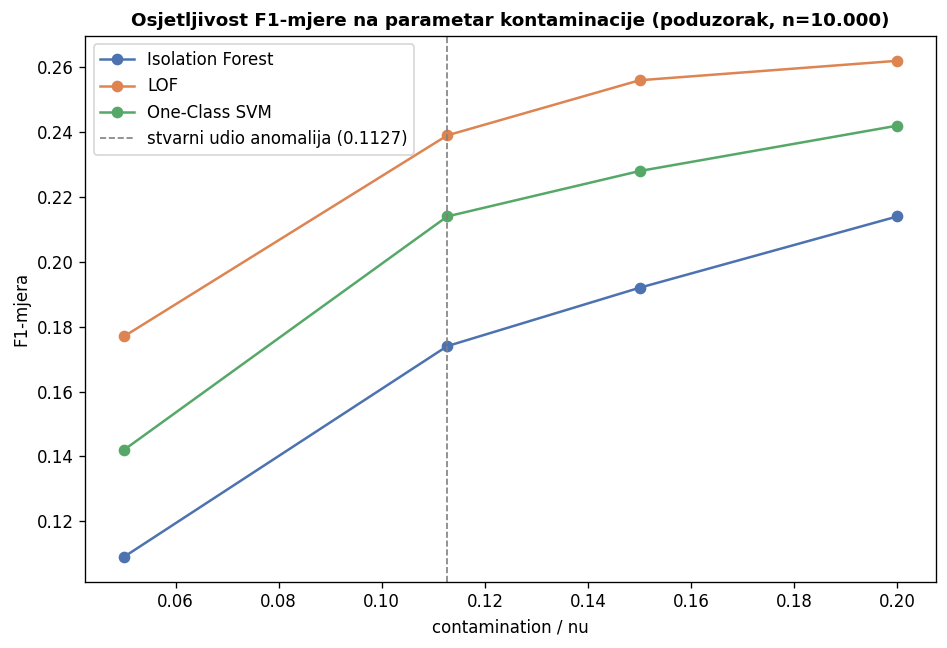

In [50]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for name in model_names:
    sub = sensitivity_df[sensitivity_df['Model'] == name]
    ax.plot(sub['contamination'], sub['F1'], marker='o', label=name, color=MODEL_COLORS[name])

ax.axvline(CONTAMINATION, linestyle='--', color='gray', linewidth=1,
           label=f'stvarni udio anomalija ({CONTAMINATION})')
ax.set_xlabel('contamination / nu')
ax.set_ylabel('F1-mjera')
ax.set_title('Osjetljivost F1-mjere na parametar kontaminacije (poduzorak, n=10.000)')
ax.legend()
fig.tight_layout()
fig.savefig(f'{SLIKE_DIR}/osjetljivost_kontaminacije.png')
plt.show()


## 5.5 Dodatna analiza: ansambl (unija/presjek) triju modela

Poglavlje 6 (Rasprava, prijedlog za buduća istraživanja) razmatra kombiniranje sva tri modela u
jednostavan ansambl. Bez ponovnog treniranja, iz već izračunatih predikcija na poduzorku
(`iso_pred_sub`, `lof_pred_sub`, `ocsvm_pred_sub`) mogu se izravno izvesti dva pravila glasovanja:
zapis je anomalija ako ga kao takvog označi **barem jedan** model (unija) ili **sva tri** modela
(presjek). Oba se pravila evaluiraju protiv iste proxy reference `y_sub` kao i pojedinačni modeli
u odjeljku 4.5.

In [51]:
iso_anom_b = (iso_pred_sub == -1)
lof_anom_b = (lof_pred_sub == -1)
ocsvm_anom_b = (ocsvm_pred_sub == -1)
n_models_flagged = iso_anom_b.astype(int) + lof_anom_b.astype(int) + ocsvm_anom_b.astype(int)

union_pred = (n_models_flagged >= 1).astype(int)      # barem jedan model
intersection_pred = (n_models_flagged == 3).astype(int)  # sva tri modela

ensemble_rows = []
for name, pred_bin in [('Unija (barem jedan model)', union_pred),
                        ('Presjek (sva tri modela)', intersection_pred)]:
    ensemble_rows.append({
        'Pravilo': name,
        'Broj označenih anomalija': int(pred_bin.sum()),
        'Precision': round(precision_score(y_sub, pred_bin, zero_division=0), 3),
        'Recall': round(recall_score(y_sub, pred_bin, zero_division=0), 3),
        'F1-mjera': round(f1_score(y_sub, pred_bin, zero_division=0), 3),
    })

ensemble_df = pd.DataFrame(ensemble_rows)
ensemble_df.to_csv(f'{REZULTATI_DIR}/5_5_ansambl_unija_presjek.csv', index=False)
print('Za usporedbu, pojedinačni modeli (odjeljak 4.5):')
print(eval_summary[['Precision', 'Recall', 'F1-mjera']])
print()
ensemble_df

Za usporedbu, pojedinačni modeli (odjeljak 4.5):
                  Precision  Recall  F1-mjera
Isolation Forest      0.161   0.155     0.158
LOF                   0.239   0.238     0.239
One-Class SVM         0.214   0.214     0.214



,Pravilo,Broj označenih anomalija,Precision,Recall,F1-mjera
0,Unija (barem jedan model),2034,0.192,0.346,0.247
1,Presjek (sva tri modela),332,0.250,0.074,0.114
